# Advanced Retrieval with LangChain

In the following notebook, we'll explore various methods of advanced retrieval using LangChain!

We'll touch on:

- Naive Retrieval
- Best-Matching 25 (BM25)
- Multi-Query Retrieval
- Parent-Document Retrieval
- Contextual Compression (a.k.a. Rerank)
- Ensemble Retrieval
- Semantic chunking

We'll also discuss how these methods impact performance on our set of documents with a simple RAG chain.

There will be two breakout rooms:

- 🤝 Breakout Room Part #1
  - Task 1: Getting Dependencies!
  - Task 2: Data Collection and Preparation
  - Task 3: Setting Up QDrant!
  - Task 4-10: Retrieval Strategies
- 🤝 Breakout Room Part #2
  - Activity: Evaluate with Ragas

# 🤝 Breakout Room Part #1

## Task 1: Getting Dependencies!

We're going to need a few specific LangChain community packages, like OpenAI (for our [LLM](https://platform.openai.com/docs/models) and [Embedding Model](https://platform.openai.com/docs/guides/embeddings)) and Cohere (for our [Reranker](https://cohere.com/rerank)).

We'll also provide our OpenAI key, as well as our Cohere API key.

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

In [2]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

## Task 2: Data Collection and Preparation

We'll be using our Use Case Data once again - this time the strutured data available through the CSV!

### Data Preparation

We want to make sure all our documents have the relevant metadata for the various retrieval strategies we're going to be applying today.

In [3]:
# from langchain_community.document_loaders.csv_loader import CSVLoader
# from datetime import datetime, timedelta

# loader = CSVLoader(
#     file_path=f"./data/Projects_with_Domains.csv",
#     metadata_columns=[
#       "Project Title",
#       "Project Domain",
#       "Secondary Domain",
#       "Description",
#       "Judge Comments",
#       "Score",
#       "Project Name",
#       "Judge Score"
#     ]
# )

# synthetic_usecase_data = loader.load()

# for doc in synthetic_usecase_data:
#     doc.page_content = doc.metadata["Description"]

In [4]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from datetime import datetime, timedelta

loader = CSVLoader(
    file_path=f"./data/arxiv_cleaned_sample.csv",
    metadata_columns=[
      "id",
      "title",
      "abstract",
      "categories",
      "authors",
    ],
    source_column="combined_text"
)

synthetic_arxiv_data = loader.load()


Let's look at an example document to see if everything worked as expected!

In [5]:
synthetic_arxiv_data[0]

Document(metadata={'source': "Title: Calculation of prompt diphoton production cross sections at Tevatron and LHC energies. Authors: C. Bal\\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan. Categories: hep-ph. Abstract: A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. All next-to-leading order perturbative contributions from quark-antiquark, gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as all-orders resummation of initial-state gluon radiation valid at next-to-next-to-leading logarithmic accuracy. The region of phase space is specified in which the calculation is most reliable. Good agreement is demonstrated with data from the Fermilab Tevatron, and predictions are made for more detailed tests with CDF and DO data. Predictions are shown for distributions of diphoton pairs produced at the energy of the Large Hadron Collider (LHC). Distributions of the diphoton pair

## Task 3: Setting up QDrant!

Now that we have our documents, let's create a QDrant VectorStore with the collection name "Synthetic_Usecases".

We'll leverage OpenAI's [`text-embedding-3-small`](https://openai.com/blog/new-embedding-models-and-api-updates) because it's a very powerful (and low-cost) embedding model.

> NOTE: We'll be creating additional vectorstores where necessary, but this pattern is still extremely useful.

In [6]:
from langchain_community.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Qdrant.from_documents(
    synthetic_arxiv_data,
    embeddings,
    location=":memory:",
    collection_name="Synthetic_Arxiv_Data"
)

## Task 4: Naive RAG Chain

Since we're focusing on the "R" in RAG today - we'll create our Retriever first.

### R - Retrieval

This naive retriever will simply look at each review as a document, and use cosine-similarity to fetch the 10 most relevant documents.

> NOTE: We're choosing `10` as our `k` here to provide enough documents for our reranking process later

In [7]:
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 10})

### A - Augmented

We're going to go with a standard prompt for our simple RAG chain today! Nothing fancy here, we want this to mostly be about the Retrieval process.

In [8]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

### G - Generation

We're going to leverage `gpt-4.1-nano` as our LLM today, as - again - we want this to largely be about the Retrieval process.

In [9]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4.1-nano")

### LCEL RAG Chain

We're going to use LCEL to construct our chain.

> NOTE: This chain will be exactly the same across the various examples with the exception of our Retriever!

In [10]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

naive_retrieval_chain = (
    # INVOKE CHAIN WITH: {"question" : "<<SOME USER QUESTION>>"}
    # "question" : populated by getting the value of the "question" key
    # "context"  : populated by getting the value of the "question" key and chaining it into the base_retriever
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    # "context"  : is assigned to a RunnablePassthrough object (will not be called or considered in the next step)
    #              by getting the value of the "context" key from the previous step
    | RunnablePassthrough.assign(context=itemgetter("context"))
    # "response" : the "context" and "question" values are used to format our prompt object and then piped
    #              into the LLM and stored in a key called "response"
    # "context"  : populated by getting the value of the "context" key from the previous step
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's see how this simple chain does on a few different prompts.

> NOTE: You might think that we've cherry picked prompts that showcase the individual skill of each of the retrieval strategies - you'd be correct!

In [11]:
naive_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'Among the provided documents, several papers discuss diphoton production or related cross sections in particle physics:\n\n1. **"Calculation of prompt diphoton production cross sections at Tevatron and LHC energies"**  \n   - Focuses on a detailed QCD calculation of diphoton (massive photon pairs) production at hadron colliders, including NLO contributions and resummations.  \n   - Abstract: "A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders."\n\n2. **"Direct photons and dileptons via color dipoles"**  \n   - Discusses inclusive direct photon production, which is related to photon production cross sections, including at the Tevatron.\n\n3. **"Electromagnetic Higgs production"**  \n   - Mentions Higgs production via photon fusion, related to photon cross sections, but not specifically diphoton cross sections.\n\nThe most comprehensive paper explicitly dedicated to diphoton production cross

In [12]:
naive_retrieval_chain.invoke({"question" : "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'Based on the provided information, the following papers study Stirling numbers or combinatorial determinants:\n\n1. **"A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata"** by David Callan (arXiv:0704.0004).  \n   - This paper discusses a determinant involving Stirling cycle numbers and relates it to counting unlabeled acyclic automata.\n\n2. **"Almost Product Evaluation of Hankel Determinants"** by Omer Egecioglu, Timothy Redmond, Charles Ryavec (arXiv:0704.3398).  \n   - Focuses on Hankel determinants, which are connected to combinatorial sequences and determinants evaluations, including those involving binomial coefficients that relate to Stirling-type numbers.\n\n3. **"Determinant Formulas Relating to Tableaux of Bounded Height"** by Guoce Xin (arXiv:0704.3381).  \n   - Deals with determinants associated with tableaux, which often involve combinatorial determinants and may relate to Stirling numbers.\n\n4. **"Determinant formulas relating to ta

In [13]:
naive_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan.'

In [14]:
naive_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Λα (Lambda-alpha) function spaces is titled "From dyadic Λα to Λα" by Wael Abu-Shammala and Alberto Torchinsky.'

In [15]:
naive_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled "Sparsity-certifying Graph Decompositions" by Ileana Streinu and Louis Theran.'

Overall, this is not bad! Let's see if we can make it better!

## Task 5: Best-Matching 25 (BM25) Retriever

Taking a step back in time - [BM25](https://www.nowpublishers.com/article/Details/INR-019) is based on [Bag-Of-Words](https://en.wikipedia.org/wiki/Bag-of-words_model) which is a sparse representation of text.

In essence, it's a way to compare how similar two pieces of text are based on the words they both contain.

This retriever is very straightforward to set-up! Let's see it happen down below!


In [16]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(synthetic_arxiv_data)

We'll construct the same chain - only changing the retriever.

In [17]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at the responses!

In [18]:
bm25_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The first document, titled "Calculation of prompt diphoton production cross sections at Tevatron and LHC energies," discusses diphoton production and cross sections in particle physics.'

In [19]:
bm25_retrieval_chain.invoke({"question" : "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'There are several papers in the provided context that study Stirling numbers or combinatorial determinants. Here are some notable ones:\n\n1. **"A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata"** by David Callan.  \n   This paper investigates determinants involving Stirling cycle numbers and provides combinatorial interpretations related to automata theory.\n\n2. **"Combinatorics and Boson normal ordering: A gentle introduction"** by P. Blasiak, A. Horzela, K. A. Penson, A. I. Solomon, G. H. E. Duchamp.  \n   This work discusses a combinatorial framework for operator ordering problems, where the solutions involve Bell and Stirling numbers, which are key concepts in combinatorics and number theory.\n\nBoth papers study aspects of Stirling numbers within a combinatorial or algebraic context.'

In [20]:
bm25_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled "Modelling long-term trends in lunar exposure to the Earth\'s plasmasheet" by Mike Hapgood. It discusses the precession of the Moon\'s orbit around the Earth, which completes a revolution every 18.6 years and influences various astronomical phenomena, including the evolution of the Moon\'s apparent orbit over time.'

In [21]:
bm25_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'I do not know of a study that specifically connects harmonic analysis and Λα (Lambda-alpha) function spaces based on the provided context.'

In [22]:
bm25_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'Based on the provided context, the paper that introduces a sparsity-certifying algorithm for graph decomposition is not explicitly mentioned. The documents primarily discuss algorithms related to Hamiltonian graphs, traveling salesman problems, metric dimension and diameter in graphs, anisotropic diffusion in hydrogen-bonded networks, and belief propagation for weighted matching. None of these specifically focus on a sparsity-certifying algorithm for graph decomposition.\n\nTherefore, I do not know the specific paper that introduces a sparsity-certifying algorithm for graph decomposition.'

It's not clear that this is better or worse, if only we had a way to test this (SPOILERS: We do, the second half of the notebook will cover this)

#### ❓ Question #1:

Give an example query where BM25 is better than embeddings and justify your answer.

##### ✅ Answer

**Example Query:** "Which paper investigates how the Moon's orbit evolves over time?"

**Analysis of Responses:**

**Naive Retriever (Embeddings) Response:**
- Found: "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan
- This paper focuses on dark matter field fluid models affecting the Earth-Moon system

**BM25 Response:**
- Found: "Modelling long-term trends in lunar exposure to the Earth's plasmasheet" by Mike Hapgood
- This paper specifically discusses "the precession of the Moon's orbit around the Earth, which completes a revolution every 18.6 years and influences various astronomical phenomena, including the evolution of the Moon's apparent orbit over time"

**Why BM25 is Better:**

1. **More Direct Match to Query Intent**: The BM25 result directly addresses "how the Moon's orbit evolves over time" by discussing orbital precession and long-term orbital trends. The naive retriever found a paper about dark matter effects, which is more tangentially related.

2. **Keyword Precision**: BM25 likely matched key terms like "orbit," "Moon," and "evolution/evolves" more precisely. The query asks specifically about orbital evolution, and BM25 found a paper that explicitly discusses orbital mechanics.

3. **Temporal Focus**: The query asks about evolution "over time," and the BM25 result specifically mentions "long-term trends" and "18.6 years" cycles, showing it captured the temporal aspect better.

4. **Specificity vs. Generality**: While the embedding-based result discusses the Earth-Moon system broadly through a dark matter lens, the BM25 result is specifically focused on orbital dynamics and evolution, which is exactly what the query requested.

This demonstrates BM25's strength in matching specific technical concepts and maintaining focus on the precise aspects mentioned in the query, rather than retrieving semantically related but less directly relevant content.

## Task 6: Contextual Compression (Using Reranking)

Contextual Compression is a fairly straightforward idea: We want to "compress" our retrieved context into just the most useful bits.

There are a few ways we can achieve this - but we're going to look at a specific example called reranking.

The basic idea here is this:

- We retrieve lots of documents that are very likely related to our query vector
- We "compress" those documents into a smaller set of *more* related documents using a reranking algorithm.

We'll be leveraging Cohere's Rerank model for our reranker today!

All we need to do is the following:

- Create a basic retriever
- Create a compressor (reranker, in this case)

That's it!

Let's see it in the code below!

In [23]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-v3.5")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

Let's create our chain again, and see how this does!

In [24]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [25]:
contextual_compression_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The paper that discusses diphoton production or cross sections in particle physics is titled "Calculation of prompt diphoton production cross sections at Tevatron and LHC energies," authored by C. Balázs, E. L. Berger, P. M. Nadolsky, and C.-P. Yuan. It presents a detailed calculation of diphoton production cross sections at hadron colliders, including all relevant perturbative contributions and comparisons with experimental data.'

In [26]:
contextual_compression_retrieval_chain.invoke({"question" :  "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'The paper that studies Stirling numbers is titled "A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata" by David Callan.'

In [27]:
contextual_compression_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper titled "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan investigates how the Moon’s orbit evolves over time.'

In [28]:
contextual_compression_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Λα (Lambda-alpha) function spaces is titled "From dyadic Λα to Λα" by Wael Abu-Shammala and Alberto Torchinsky.'

In [29]:
contextual_compression_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled "Sparsity-certifying Graph Decompositions" by Ileana Streinu and Louis Theran.'

We'll need to rely on something like Ragas to help us get a better sense of how this is performing overall - but it "feels" better!

## Task 7: Multi-Query Retriever

Typically in RAG we have a single query - the one provided by the user.

What if we had....more than one query!

In essence, a Multi-Query Retriever works by:

1. Taking the original user query and creating `n` number of new user queries using an LLM.
2. Retrieving documents for each query.
3. Using all unique retrieved documents as context

So, how is it to set-up? Not bad! Let's see it down below!



In [30]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
) 

In [31]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [32]:
multi_query_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The paper that discusses diphoton production or cross sections in particle physics is titled "Calculation of prompt diphoton production cross sections at Tevatron and LHC energies." Its abstract indicates that it presents a fully differential calculation within perturbative QCD for massive photon pair production at hadron colliders, including all NLO contributions and all-orders resummation, with predictions and comparisons to Tevatron and LHC data.'

In [33]:
multi_query_retrieval_chain.invoke({"question" :  "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'The paper that studies Stirling numbers or combinatorial determinants is titled "A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata" by David Callan.'

In [34]:
multi_query_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan. It discusses the general pattern of the Moon-Earth system\'s evolution, including how the closest distance of the Moon to Earth was much greater in the past and how the system\'s behavior aligns with geological and fossil evidence.'

In [35]:
multi_query_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Λα (Lambda-alpha) function spaces is titled "From dyadic Λα to Λα" by Wael Abu-Shammala and Alberto Torchinsky. This paper demonstrates how to compute the Λα norm using the dyadic grid and relates the Λα spaces to the Hardy spaces H^p(R^N) in terms of dyadic and special atoms, establishing a link between harmonic analysis techniques and the structure of Λα function spaces.'

In [36]:
multi_query_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled "Sparsity-certifying Graph Decompositions" by Ileana Streinu and Louis Theran.'

#### ❓ Question #2:

Explain how generating multiple reformulations of a user query can improve recall.

##### ✅ Answer

Generating multiple reformulations of a user query improves recall through several key mechanisms:

**1. Vocabulary Mismatch Resolution**
- Users often express the same concept using different terminology than what appears in documents
- Multiple reformulations can capture alternative phrasings, synonyms, and domain-specific terminology
- Example: A user asking "machine learning algorithms" might miss documents that use "artificial intelligence methods" or "statistical learning techniques"

**2. Perspective Diversification**
- Different reformulations can approach the same topic from various angles
- This captures documents that discuss the concept from different viewpoints or contexts
- Example: Reformulating "climate change effects" into "global warming impacts," "environmental consequences," and "ecological disruption" would retrieve different but relevant document sets

**3. Specificity and Generality Balance**
- Some reformulations can be more specific while others more general
- Specific queries find highly targeted documents, while general queries catch broader relevant content
- This creates a wider net that captures both focused and contextual information

**4. Semantic Space Coverage**
- Each reformulation creates a different vector representation in embedding space
- Multiple queries explore different regions of the semantic space
- This increases the likelihood of finding relevant documents that might be semantically distant from the original query but close to a reformulation

**5. Query Ambiguity Handling**
- Original queries may be ambiguous or incomplete
- Reformulations can disambiguate by exploring different interpretations
- This ensures relevant documents aren't missed due to unclear user intent

**6. Document Diversity**
- Different reformulations may retrieve overlapping but distinct document sets
- The union of these sets provides higher recall than any single query
- This is particularly valuable when documents use varied terminology or discuss topics from different disciplinary perspectives

**Mathematical Perspective:**
If each query has recall R₁, R₂, ..., Rₙ, the combined recall approaches R₁ ∪ R₂ ∪ ... ∪ Rₙ, which is typically much larger than any individual Rᵢ.

🔍 Example from the arXiv dataset:
For the query “Photon production”, a single embedding query may miss the target paper
“Calculation of prompt diphoton production cross sections at Tevatron and LHC energies.”
However, a reformulated query like “diphoton production in hadron collisions” retrieves it successfully, demonstrating higher recall through query diversification.

✅ Conclusion:

This multi-query approach essentially casts a wider retrieval net, increasing the probability of capturing all relevant documents in the corpus.


## Task 8: Parent Document Retriever

A "small-to-big" strategy - the Parent Document Retriever works based on a simple strategy:

1. Each un-split "document" will be designated as a "parent document" (You could use larger chunks of document as well, but our data format allows us to consider the overall document as the parent chunk)
2. Store those "parent documents" in a memory store (not a VectorStore)
3. We will chunk each of those documents into smaller documents, and associate them with their respective parents, and store those in a VectorStore. We'll call those "child chunks".
4. When we query our Retriever, we will do a similarity search comparing our query vector to the "child chunks".
5. Instead of returning the "child chunks", we'll return their associated "parent chunks".

Okay, maybe that was a few steps - but the basic idea is this:

- Search for small documents
- Return big documents

The intuition is that we're likely to find the most relevant information by limiting the amount of semantic information that is encoded in each embedding vector - but we're likely to miss relevant surrounding context if we only use that information.

Let's start by creating our "parent documents" and defining a `RecursiveCharacterTextSplitter`.

In [37]:
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models

parent_docs = synthetic_arxiv_data
child_splitter = RecursiveCharacterTextSplitter(chunk_size=750)

We'll need to set up a new QDrant vectorstore - and we'll use another useful pattern to do so!

> NOTE: We are manually defining our embedding dimension, you'll need to change this if you're using a different embedding model.

In [38]:
from langchain_qdrant import QdrantVectorStore

client = QdrantClient(location=":memory:")

client.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

parent_document_vectorstore = QdrantVectorStore(
    collection_name="full_documents", embedding=OpenAIEmbeddings(model="text-embedding-3-small"), client=client
)

Now we can create our `InMemoryStore` that will hold our "parent documents" - and build our retriever!

In [39]:
store = InMemoryStore()

parent_document_retriever = ParentDocumentRetriever(
    vectorstore = parent_document_vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

By default, this is empty as we haven't added any documents - let's add some now!

In [40]:
parent_document_retriever.add_documents(parent_docs, ids=None)

We'll create the same chain we did before - but substitute our new `parent_document_retriever`.

In [41]:
parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's give it a whirl!

In [42]:
parent_document_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The paper that discusses diphoton production or cross sections in particle physics is titled "Calculation of prompt diphoton production cross sections at Tevatron and LHC energies" by C. Balázs, E. L. Berger, P. M. Nadolsky, and C.-P. Yuan.'

In [43]:
parent_document_retrieval_chain.invoke({"question" : "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'Based on the provided information, there are two papers that study Stirling numbers or combinatorial determinants:\n\n1. **"A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata"** by David Callan.  \n   - Focuses on the determinant of Stirling cycle numbers and their combinatorial interpretation related to automata.\n\n2. **"Combinatorics and Boson normal ordering: A gentle introduction"** by P. Blasiak et al.  \n   - Discusses Stirling numbers in the context of operator ordering problems, relating combinatorial objects to these numbers.\n\nAdditionally, there is a paper titled **"Almost Product Evaluation of Hankel Determinants"** by Omer Egecioglu, Timothy Redmond, and Charles Ryavec, which studies Hankel determinants, some of which may involve combinatorial numbers like Stirling numbers, but the primary focus appears to be on the evaluation of Hankel determinants themselves.\n\n**Summary:**  \nThe most relevant paper studying Stirling numbers dire

In [44]:
parent_document_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan.'

In [45]:
parent_document_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Λα (Lambda-alpha) function spaces is titled "From dyadic Λα to Λα," authored by Wael Abu-Shammala and Alberto Torchinsky.'

In [46]:
parent_document_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled **"Sparsity-certifying Graph Decompositions"** by Ileana Streinu and Louis Theran.'

Overall, the performance *seems* largely the same. We can leverage a tool like [Ragas]() to more effectively answer the question about the performance.

## Task 9: Ensemble Retriever

In brief, an Ensemble Retriever simply takes 2, or more, retrievers and combines their retrieved documents based on a rank-fusion algorithm.

In this case - we're using the [Reciprocal Rank Fusion](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf) algorithm.

Setting it up is as easy as providing a list of our desired retrievers - and the weights for each retriever.

In [49]:
from langchain.retrievers import EnsembleRetriever

retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
equal_weighting = [1/len(retriever_list)] * len(retriever_list)

ensemble_retriever = EnsembleRetriever(
    retrievers=retriever_list, weights=equal_weighting
)

We'll pack *all* of these retrievers together in an ensemble.

In [50]:
ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at our results!

In [51]:
ensemble_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The paper that discusses diphoton production or cross sections in particle physics is titled:\n\n**"Calculation of prompt diphoton production cross sections at Tevatron and LHC energies"**\n\nIt presents a fully differential perturbative QCD calculation for the production of photon pairs at hadron colliders, including next-to-leading order contributions and resummation techniques. The abstract details their focus on diphoton distributions, agreement with Tevatron data, and predictions for LHC energies, explicitly addressing diphoton production cross sections.'

In [52]:
ensemble_retrieval_chain.invoke({"question" : "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'Based on the provided documents, here are some papers that study Stirling numbers or combinatorial determinants:\n\n1. **"A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata" by David Callan**  \n   - Abstract: The paper shows that a determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata, involving bijections to marked lattice paths and sign-reversing involutions.  \n   - Categories: math.CO\n\n2. **"Almost Product Evaluation of Hankel Determinants" by Omer Egecioglu, Timothy Redmond, Charles Ryavec**  \n   - Abstract: The authors evaluate Hankel determinants related to binomial entries, providing product and almost product formulas.  \n   - Categories: math.CO\n\n3. **"Determinant Formulas Relating to Tableaux of Bounded Height" by Guoce Xin**  \n   - Abstract: The paper develops determinant formulas for generating functions connected to oscillating tableaux and permutations with bounded increasing subsequences, which

In [53]:
ensemble_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled **"The evolution of the Earth-Moon system based on the dark matter field fluid model"** by Hongjun Pan. It discusses the orbital evolution of the Earth-Moon system, including the Moon\'s historical distance from Earth and how models explain its long-term behavior.'

In [54]:
ensemble_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Lambda-alpha (Λα) function spaces is titled "From dyadic Λα to Λα" by Wael Abu-Shammala and Alberto Torchinsky. It discusses how to compute the Λα norm using the dyadic grid, which relates to harmonic analysis, and describes the Λα spaces in terms of dyadic and special atoms, thereby linking harmonic analysis to the study of these function spaces.'

In [55]:
ensemble_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled **"Sparsity-certifying Graph Decompositions"** by Ileana Streinu and Louis Theran.'

## Task 10: Semantic Chunking

While this is not a retrieval method - it *is* an effective way of increasing retrieval performance on corpora that have clean semantic breaks in them.

Essentially, Semantic Chunking is implemented by:

1. Embedding all sentences in the corpus.
2. Combining or splitting sequences of sentences based on their semantic similarity based on a number of [possible thresholding methods](https://python.langchain.com/docs/how_to/semantic-chunker/):
  - `percentile`
  - `standard_deviation`
  - `interquartile`
  - `gradient`
3. Each sequence of related sentences is kept as a document!

Let's see how to implement this!

We'll use the `percentile` thresholding method for this example which will:

Calculate all distances between sentences, and then break apart sequences of setences that exceed a given percentile among all distances.

In [56]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

Now we can split our documents.

In [57]:
semantic_documents = semantic_chunker.split_documents(synthetic_arxiv_data[:20])

Let's create a new vector store.

In [58]:
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="Synthetic_Arxiv_data_Semantic_Chunks"
)

We'll use naive retrieval for this example.

In [59]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 10})

Finally we can create our classic chain!

In [60]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

And view the results!

In [61]:
semantic_retrieval_chain.invoke({"question" : "Which paper discusses diphoton production or cross sections in particle physics?"})["response"].content

'The paper that discusses diphoton production and cross sections in particle physics is titled "Calculation of prompt diphoton production cross sections at Tevatron and LHC energies" by C. Balázs, E. L. Berger, P. M. Nadolsky, and C.-P. Yuan.'

In [62]:
semantic_retrieval_chain.invoke({"question" : "Find the paper that studies Stirling numbers or combinatorial determinants."})["response"].content

'The paper that studies Stirling numbers or combinatorial determinants is titled "A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata" by David Callan. The abstract indicates that it involves determinants related to Stirling cycle numbers and their combinatorial counting interpretations.'

In [63]:
semantic_retrieval_chain.invoke({"question" : "Which paper investigates how the Moon’s orbit evolves over time?"})["response"].content

'The paper that investigates how the Moon’s orbit evolves over time is titled "The evolution of the Earth-Moon system based on the dark matter field fluid model" by Hongjun Pan.'

In [64]:
semantic_retrieval_chain.invoke({"question" : "Which study connects harmonic analysis and Λα (Lambda-alpha) function spaces?"})["response"].content

'The study that connects harmonic analysis and Λα (Lambda-alpha) function spaces is titled "From dyadic Λα to Λα" by Wael Abu-Shammala and Alberto Torchinsky.'

In [65]:
semantic_retrieval_chain.invoke({"question" : "What is the paper that introduces a sparsity-certifying algorithm for graph decomposition?"})["response"].content

'The paper that introduces a sparsity-certifying algorithm for graph decomposition is titled **"Sparsity-certifying Graph Decompositions"**, authored by Ileana Streinu and Louis Theran.'

#### ❓ Question #3:

If sentences are short and highly repetitive (e.g., FAQs), how might semantic chunking behave, and how would you adjust the algorithm?

##### ✅ Answer

**How Semantic Chunking Would Behave with Short, Repetitive Sentences:**

**1. Problematic Behaviors:**
- **Over-fragmentation**: Short sentences would likely result in very small chunks, potentially creating one chunk per sentence or question-answer pair
- **High similarity scores**: Repetitive language patterns (e.g., "How do I...", "What is...", "Can I...") would create artificially high semantic similarity between unrelated topics
- **Poor breakpoint detection**: The algorithm might fail to identify meaningful topic boundaries because structural similarities overshadow content differences
- **Inconsistent chunking**: Similar FAQ formats might be grouped together regardless of their actual topic relevance

**2. Specific Issues:**
- **Template language interference**: Common FAQ phrases like "Please contact support" or "For more information" would create false semantic connections
- **Question format bias**: Questions with similar grammatical structures but different topics might be incorrectly grouped
- **Insufficient context**: Short sentences provide limited semantic information for meaningful similarity calculations

**Algorithm Adjustments:**

**1. Preprocessing Modifications:**
- **Content extraction**: Remove common FAQ template language and focus on core content words
- **Question-answer pairing**: Treat Q&A pairs as single semantic units rather than separate sentences
- **Keyword emphasis**: Weight domain-specific terms more heavily than structural/template words

**2. Threshold Adjustments:**
- **Lower similarity thresholds**: Use more stringent breakpoint thresholds to prevent over-grouping of structurally similar but topically different content
- **Adaptive thresholding**: Implement dynamic thresholds based on content length and repetitiveness metrics

**3. Enhanced Similarity Metrics:**
- **Content-focused embeddings**: Use embeddings that emphasize semantic content over syntactic structure
- **Topic modeling integration**: Incorporate topic modeling (e.g., LDA) to identify thematic boundaries beyond pure semantic similarity
- **Named entity recognition**: Weight entities and domain-specific terms more heavily in similarity calculations

**4. Structural Awareness:**
- **FAQ-specific chunking**: Implement FAQ-aware chunking that respects question-answer boundaries
- **Topic header detection**: Use FAQ section headers or categories as hard boundaries
- **Minimum chunk size**: Enforce minimum chunk sizes to prevent over-fragmentation

**5. Hybrid Approaches:**
- **Rule-based boundaries**: Combine semantic chunking with rule-based topic detection
- **Metadata utilization**: Leverage FAQ categories or tags if available
- **Manual seed boundaries**: Use predefined topic boundaries as starting points for semantic refinement

**Example Implementation Strategy:**
```
1. Preprocess: Remove template language, pair Q&As
2. Apply topic modeling to identify major themes
3. Use semantic chunking within topic boundaries
4. Enforce minimum chunk sizes (e.g., 3-5 Q&A pairs)
5. Post-process to merge overly small chunks
```

**Summary**:

Semantic chunking on repetitive data can mistake structure for meaning.
By preprocessing, adjusting thresholds, and combining semantic with rule-based cues, you can form larger, topic-coherent chunks and greatly improve retrieval quality.

# 🤝 Breakout Room Part #2

#### 🏗️ Activity #1

Your task is to evaluate the various Retriever methods against eachother.

You are expected to:

1. Create a "golden dataset"
 - Use Synthetic Data Generation (powered by Ragas, or otherwise) to create this dataset
2. Evaluate each retriever with *retriever specific* Ragas metrics
 - Semantic Chunking is not considered a retriever method and will not be required for marks, but you may find it useful to do a "semantic chunking on" vs. "semantic chunking off" comparision between them
3. Compile these in a list and write a small paragraph about which is best for this particular data and why.

Your analysis should factor in:
  - Cost
  - Latency
  - Performance

> NOTE: This is **NOT** required to be completed in class. Please spend time in your breakout rooms creating a plan before moving on to writing code.

##### HINTS:

- LangSmith provides detailed information about latency and cost.

In [ ]:
### YOUR CODE HERE

## __Section 1: Setup and Imports__

Import all necessary libraries for Ragas 0.37 evaluation, LangSmith tracing, and performance tracking.


In [ ]:

"""
# Section 1: Enhanced Setup and Dependencies with LangSmith

This section imports all necessary libraries and sets up comprehensive LangSmith tracing:
- **LangSmith Tracing**: Full integration with @traceable decorators
- **Enhanced Performance Tracking**: Real-time cost and latency monitoring
- **Production-Grade Monitoring**: Complete audit trails and analytics
- **Ragas & LangChain**: All original functionality maintained
- **Advanced Visualization**: Enhanced charts with tracing data

We'll configure LangSmith for production-grade monitoring and debugging.
"""

# Core imports
import os
import time
import json
import pandas as pd
import numpy as np
from datetime import datetime
from typing import List, Dict, Any, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# LangSmith imports and setup
from langsmith import traceable, Client
from langchain.callbacks.tracers import LangChainTracer

# LangChain imports
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_community.vectorstores import Qdrant
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain.retrievers import ParentDocumentRetriever, EnsembleRetriever
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank
from langchain.storage import InMemoryStore
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

# Ragas imports
from ragas.testset import TestsetGenerator
# from ragas.testset.evolutions import simple, reasoning, multi_context
from ragas import evaluate, EvaluationDataset, SingleTurnSample
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import (
    context_precision,
    context_recall,
    # ContextRelevance as context_relevancy,
    # context_relevancy,
    answer_relevancy,
    faithfulness
)

# Qdrant and performance tracking
from qdrant_client import QdrantClient, models
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ All dependencies imported successfully!")



✅ All dependencies imported successfully!


In [4]:
import ragas
print("Ragas version:", ragas.__version__)
import pymupdf
print(f"PyMuPDF version: {pymupdf.__version__}")

Ragas version: 0.3.7.dev12+gdd29e7031
PyMuPDF version: 1.26.5


In [5]:
# Set up LangSmith environment
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "retriever-evaluation-enhanced"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("Enter your LangChain API Key:")
# Ensure LANGCHAIN_API_KEY is set in your environment

# LangSmith client initialization
try:
    langsmith_client = Client()
    LANGSMITH_AVAILABLE = True
    print("✅ LangSmith client initialized successfully!")
    print(f"📊 Project: {os.environ.get('LANGCHAIN_PROJECT', 'default')}")
except Exception as e:
    LANGSMITH_AVAILABLE = False
    print(f"⚠️ LangSmith initialization failed: {e}")
    print("📊 Continuing with basic performance tracking...")


print(f"🔍 LangSmith tracing enabled: {LANGSMITH_AVAILABLE}")

✅ LangSmith client initialized successfully!
📊 Project: retriever-evaluation-enhanced
🔍 LangSmith tracing enabled: True


## __Section 2: Document Loading and Preparation__

Load PDF documents from the data directory and create standard text chunks for retrieval evaluation.


In [ ]:
"""
# Section 2: Enhanced Document Loading and Preparation with Tracing

Here we load and prepare the "howpeopleuseai.pdf" document with full tracing:
- **PDF Loading**: Use PyPDFLoader with automatic tracing
- **Text Splitting**: Apply RecursiveCharacterTextSplitter with performance monitoring
- **Document Inspection**: Examine content with detailed logging
- **Preprocessing**: Clean and prepare documents with trace visibility

This creates our base document corpus with complete observability.
"""

def load_pdf_documents(data_dir: str = "./data/") -> List:
    """Load all PDF documents from directory using DirectoryLoader."""
    print(f"📁 Loading PDFs from directory: {data_dir}")
    
    # Create DirectoryLoader with PDF filter
    loader = DirectoryLoader(
        data_dir,
        glob="*.pdf",  # Only load PDF files
        loader_cls=PyMuPDFLoader,  # Use PyMuPDF for each PDF
        show_progress=True  # Show loading progress
    )
    
    documents = loader.load()
    
    print(f"📊 Loaded {len(documents)} pages from PDF files")
    print(f"📝 Total characters: {sum(len(doc.page_content) for doc in documents):,}")
    
    # Show which files were loaded
    unique_sources = set(doc.metadata.get('source', 'Unknown') for doc in documents)
    print(f"📄 Files loaded: {list(unique_sources)}")
    
    return documents



def create_standard_chunks(documents: List) -> List:
    """Create standard text chunks ."""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    
    chunked_documents = text_splitter.split_documents(documents)
    
    print(f"🔪 Created {len(chunked_documents)} chunks")
    print(f"📏 Average chunk size: {np.mean([len(doc.page_content) for doc in chunked_documents]):.0f} characters")
    
    return chunked_documents


def load_and_prepare_documents(data_dir: str = "./data/") -> Tuple[List, List]:
    """
    Load all PDF documents from directory and prepare for retrieval evaluation.
    
    Args:
        data_dir: Directory containing PDF files
    
    Returns:
        Tuple of (original_documents, chunked_documents)
    """
    # Load all PDFs from directory
    original_docs = load_pdf_documents(data_dir)
    
    # Create standard chunks
    standard_chunks = create_standard_chunks(original_docs)
    
    # Display sample chunk - IMPORTANT for debugging!
    if standard_chunks:
        print("\n📋 Sample chunk:")
        print("-" * 50)
        print(standard_chunks[0].page_content[:300] + "...")
        print("-" * 50)
    
    return original_docs, standard_chunks



In [7]:

# Execute document 
original_docs, standard_chunks = load_and_prepare_documents()


📁 Loading PDFs from directory: ./data/


100%|██████████| 1/1 [00:00<00:00,  6.65it/s]

📊 Loaded 64 pages from PDF files
📝 Total characters: 112,856
📄 Files loaded: ['data/howpeopleuseai.pdf']
🔪 Created 160 chunks
📏 Average chunk size: 801 characters

📋 Sample chunk:
--------------------------------------------------
NBER WORKING PAPER SERIES
HOW PEOPLE USE CHATGPT
Aaron Chatterji
Thomas Cunningham
David J. Deming
Zoe Hitzig
Christopher Ong
Carl Yan Shan
Kevin Wadman
Working Paper 34255
http://www.nber.org/papers/w34255
NATIONAL BUREAU OF ECONOMIC RESEARCH
1050 Massachusetts Avenue
Cambridge, MA 02138
September ...
--------------------------------------------------


## __Section 3: Golden Dataset Generation__

Generate a synthetic test dataset using Ragas 0.37 TestsetGenerator with 10 questions from the loaded documents.


In [ ]:

def create_synthetic_dataset(documents, test_size=10):
    """Generate synthetic evaluation dataset using Ragas 0.37."""
    print(f"🎯 Generating {test_size} questions...")
    
    # Initialize models (Ragas 0.37 style)
    generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))
    generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))
    
    # Create generator
    generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
    
    # Generate testset
    testset = generator.generate_with_langchain_docs(
        documents=documents[:20],
        testset_size=test_size
    )
    
    # Save to CSV
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"evaluation_dataset_{timestamp}.csv"
    testset.to_pandas().to_csv(filename, index=False)
    
    print(f"✅ Generated {test_size} questions!")
    print(f"💾 Saved as: {filename}")
    
    return testset  # Return native Ragas dataset


In [9]:

# # Clean metadata before generating synthetic dataset
# print("🧹 Cleaning document metadata...")
# cleaned_docs = clean_document_metadata(original_docs)

# Generate synthetic dataset 
evaluation_dataset = create_synthetic_dataset(original_docs, test_size=10)



🎯 Generating 10 questions...


Applying HeadlinesExtractor:   0%|          | 0/10 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/20 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/16 [00:00<?, ?it/s]

Property 'summary' already exists in node 'f9c695'. Skipping!
Property 'summary' already exists in node 'b7b062'. Skipping!
Property 'summary' already exists in node '250d20'. Skipping!
Property 'summary' already exists in node '015e99'. Skipping!
Property 'summary' already exists in node '802211'. Skipping!
Property 'summary' already exists in node 'aeb94c'. Skipping!


...

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Generated 10 questions!
💾 Saved as: evaluation_dataset_20251013_220338.csv


,user_input,reference_contexts,reference,synthesizer_name
0,Wut percent of the global adult population is ...,[Introduction\nChatGPT launched in November 20...,ChatGPT users represent around 10% of the glob...,single_hop_specific_query_synthesizer
1,What are the projected message counts for Chat...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,"In June 2025, the projected message counts for...",single_hop_specific_query_synthesizer
2,How might users inquire about the Boston Marat...,[Writing. Practical\nGuidance is the most comm...,Users interested in running might ask ChatGPT ...,single_hop_specific_query_synthesizer
3,How does the work of Caplin et al. relate to t...,"[Doing, and that Asking messages are consisten...",Caplin et al. (2023) argue that ChatGPT likely...,single_hop_specific_query_synthesizer
4,How do the ChatGPT message counts reflect the ...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,The ChatGPT message counts indicate a signific...,multi_hop_abstract_query_synthesizer
5,What are the ChatGPT message counts for work a...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"In June 2025, the ChatGPT message counts showe...",multi_hop_abstract_query_synthesizer
6,How does ChatGPT protect user privacy while an...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,ChatGPT protects user privacy during the analy...,multi_hop_abstract_query_synthesizer
7,What are the ChatGPT message counts for writin...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"In June 2025, the total ChatGPT message counts...",multi_hop_abstract_query_synthesizer
8,How has the usage of ChatGPT evolved in terms ...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,The usage of ChatGPT has evolved significantly...,multi_hop_specific_query_synthesizer
9,What significant milestones in the usage of Ch...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,"By July 2025, ChatGPT had reached a remarkable...",multi_hop_specific_query_synthesizer


In [10]:
# Optional: View as DataFrame
evaluation_dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,Wut percent of the global adult population is ...,[Introduction\nChatGPT launched in November 20...,ChatGPT users represent around 10% of the glob...,single_hop_specific_query_synthesizer
1,What are the projected message counts for Chat...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,"In June 2025, the projected message counts for...",single_hop_specific_query_synthesizer
2,How might users inquire about the Boston Marat...,[Writing. Practical\nGuidance is the most comm...,Users interested in running might ask ChatGPT ...,single_hop_specific_query_synthesizer
3,How does the work of Caplin et al. relate to t...,"[Doing, and that Asking messages are consisten...",Caplin et al. (2023) argue that ChatGPT likely...,single_hop_specific_query_synthesizer
4,How do the ChatGPT message counts reflect the ...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,The ChatGPT message counts indicate a signific...,multi_hop_abstract_query_synthesizer
5,What are the ChatGPT message counts for work a...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"In June 2025, the ChatGPT message counts showe...",multi_hop_abstract_query_synthesizer
6,How does ChatGPT protect user privacy while an...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,ChatGPT protects user privacy during the analy...,multi_hop_abstract_query_synthesizer
7,What are the ChatGPT message counts for writin...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"In June 2025, the total ChatGPT message counts...",multi_hop_abstract_query_synthesizer
8,How has the usage of ChatGPT evolved in terms ...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,The usage of ChatGPT has evolved significantly...,multi_hop_specific_query_synthesizer
9,What significant milestones in the usage of Ch...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,"By July 2025, ChatGPT had reached a remarkable...",multi_hop_specific_query_synthesizer


## __Section 4: Retriever Setup__

Configure all retriever methods (Naive, BM25, MultiQuery, ParentDocument, ContextualCompression, Ensemble) for evaluation.


In [ ]:

"""
# Section 4: Enhanced Retriever Implementation 


- **Naive Retriever**: Basic similarity search with performance monitoring
- **BM25 Retriever**: Keyword-based sparse retrieval with tracing
- **Multi-Query Retriever**: Multiple query reformulations with observability
- **Parent Document Retriever**: Small-to-big retrieval with detailed logging
- **Contextual Compression**: Reranking with cost and latency tracking
- **Ensemble Retriever**: Combination methods with component-level tracing

Each retriever setup is fully traced for debugging and optimization.
"""


def setup_naive_retriever(documents: List, embeddings, k: int = 10):
    """Set up naive retriever ."""
    print("📍 Setting up Naive Retriever...")
    vectorstore = Qdrant.from_documents(
        documents,
        embeddings,
        location=":memory:",
        collection_name="naive_retrieval_enhanced"
    )
    return vectorstore.as_retriever(search_kwargs={"k": k})


def setup_bm25_retriever(documents: List, k: int = 10):
    """Set up BM25 retriever."""
    print("📍 Setting up BM25 Retriever...")
    retriever = BM25Retriever.from_documents(documents)
    retriever.k = k
    return retriever


def setup_multiquery_retriever(base_retriever, llm):
    """Set up multi-query retriever."""
    print("📍 Setting up Multi-Query Retriever...")
    return MultiQueryRetriever.from_llm(retriever=base_retriever, llm=llm)


def setup_parent_document_retriever(documents: List, embeddings):
    """Set up parent document retriever."""
    print("📍 Setting up Parent Document Retriever...")
    
    # Create new vectorstore
    client = QdrantClient(location=":memory:")
    client.create_collection(
        collection_name="parent_documents_enhanced",
        vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
    )
    
    parent_vectorstore = QdrantVectorStore(
        collection_name="parent_documents_enhanced",
        embedding=embeddings,
        client=client
    )
    
    store = InMemoryStore()
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)
    
    parent_retriever = ParentDocumentRetriever(
        vectorstore=parent_vectorstore,
        docstore=store,
        child_splitter=child_splitter,
    )
    parent_retriever.add_documents(documents)
    return parent_retriever


def setup_contextual_compression_retriever(base_retriever):
    """Set up contextual compression retriever."""
    print("📍 Setting up Contextual Compression Retriever...")
    compressor = CohereRerank(model="rerank-v3.5")
    return ContextualCompressionRetriever(
        base_compressor=compressor,
        base_retriever=base_retriever
    )


def setup_ensemble_retriever(component_retrievers: List):
    """Set up ensemble retriever."""
    print("📍 Setting up Ensemble Retriever...")
    weights = [1/len(component_retrievers)] * len(component_retrievers)
    return EnsembleRetriever(retrievers=component_retrievers, weights=weights)


def setup_retrievers(documents: List, k: int = 10) -> Dict[str, Any]:
    """
    Set up all retriever methods for evaluation .
    
    Args:
        documents: List of document chunks
        k: Number of documents to retrieve
    
    Returns:
        Dictionary of retriever name -> retriever object
    """
    print(f"🔧 Setting up retrievers with k={k}...")
    
    retrievers = {}
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    llm = ChatOpenAI(model="gpt-4o-mini")
    
    # 1. Naive Retriever
    retrievers["Naive"] = setup_naive_retriever(documents, embeddings, k)
    
    # 2. BM25 Retriever
    retrievers["BM25"] = setup_bm25_retriever(documents, k)
    
    # 3. Multi-Query Retriever
    retrievers["MultiQuery"] = setup_multiquery_retriever(retrievers["Naive"], llm)
    
    # 4. Parent Document Retriever
    retrievers["ParentDocument"] = setup_parent_document_retriever(documents, embeddings)
    
    # 5. Contextual Compression Retriever
    retrievers["ContextualCompression"] = setup_contextual_compression_retriever(retrievers["Naive"])
    
    # 6. Ensemble Retriever
    ensemble_components = [retrievers["BM25"], retrievers["Naive"], retrievers["MultiQuery"]]
    retrievers["Ensemble"] = setup_ensemble_retriever(ensemble_components)
    
    print(f"✅ Successfully set up {len(retrievers)} retrievers!")
    for name in retrievers.keys():
        print(f"  - {name}")
    
    return retrievers


In [12]:

# Set up all retrievers 
standard_retrievers = setup_retrievers(standard_chunks, k=10)


🔧 Setting up retrievers with k=10...
📍 Setting up Naive Retriever...
📍 Setting up BM25 Retriever...
📍 Setting up Multi-Query Retriever...
📍 Setting up Parent Document Retriever...
📍 Setting up Contextual Compression Retriever...
📍 Setting up Ensemble Retriever...
✅ Successfully set up 6 retrievers!
  - Naive
  - BM25
  - MultiQuery
  - ParentDocument
  - ContextualCompression
  - Ensemble


## __Section 5: Performance Tracking__

Initialize performance tracking system to monitor latency and resource usage across all retriever evaluations.


In [ ]:

"""
# Section 5: Enhanced Performance Monitoring with LangSmith

Configure comprehensive performance tracking with LangSmith integration:
- **LangSmith Integration**: Real-time cost and latency monitoring
- **Enhanced Metrics**: Custom timing decorators with trace correlation
- **Resource Tracking**: Monitor API calls, token usage, and costs
- **Tracing Setup**: Detailed operation tracing for each retriever
- **Analytics**: Advanced performance analytics and insights

This ensures we capture production-grade performance data with full observability.
"""

class EnhancedPerformanceTracker:
    """Enhanced performance tracker with LangSmith integration."""
    
    def __init__(self):
        self.metrics = defaultdict(list)
        self.langsmith_client = langsmith_client if LANGSMITH_AVAILABLE else None
        self.trace_data = defaultdict(list)
        
        if LANGSMITH_AVAILABLE:
            print("✅ Enhanced LangSmith tracking initialized")
        else:
            print("⚠️ LangSmith not available, using basic tracking")
    
   
    def record_metric(self, metric_name: str, value: float, metadata: Dict = None):
        """Record a performance metric with optional metadata."""
        self.metrics[metric_name].append(value)
        
        if metadata:
            self.trace_data[metric_name].append({
                'value': value,
                'timestamp': datetime.now(),
                'metadata': metadata
            })
    
  
    def time_operation(self, operation_name: str, tags: List[str] = None):
        """Enhanced decorator to time operations ."""
        def decorator(func):
            def wrapper(*args, **kwargs):
                start_time = time.time()
                
                # Execute function with potential tracing
                if LANGSMITH_AVAILABLE and hasattr(func, '__name__'):
                    # Add tracing metadata
                    trace_tags = tags or []
                    trace_tags.extend([operation_name, "timed_operation"])
                
                result = func(*args, **kwargs)
                
                end_time = time.time()
                duration = end_time - start_time
                
                # Record metrics
                self.record_metric(
                    f"{operation_name}_latency", 
                    duration,
                    metadata={
                        'function': func.__name__,
                        'args_count': len(args),
                        'kwargs_count': len(kwargs)
                    }
                )
                
                return result
            return wrapper
        return decorator
    

    def get_summary(self) -> Dict[str, Dict[str, float]]:
        """Get enhanced summary statistics for all metrics."""
        summary = {}
        for metric_name, values in self.metrics.items():
            if values:
                summary[metric_name] = {
                    'mean': np.mean(values),
                    'std': np.std(values),
                    'min': np.min(values),
                    'max': np.max(values),
                    'count': len(values),
                    'total': np.sum(values),
                    'p95': np.percentile(values, 95),
                    'p99': np.percentile(values, 99)
                }
        return summary
    

    def get_cost_analysis(self) -> Dict[str, Any]:
        """Get cost analysis from LangSmith if available."""
        if not LANGSMITH_AVAILABLE:
            return {"error": "LangSmith not available for cost analysis"}
        
        try:
            # This would integrate with LangSmith's cost tracking
            # For now, return placeholder structure
            return {
                "total_cost": "Available in LangSmith dashboard",
                "cost_by_model": "Available in LangSmith dashboard",
                "token_usage": "Available in LangSmith dashboard"
            }
        except Exception as e:
            return {"error": f"Cost analysis failed: {e}"}

# Initialize enhanced performance tracker
performance_tracker = EnhancedPerformanceTracker()

print("📊 Enhanced performance tracking initialized!")

✅ Enhanced LangSmith tracking initialized
📊 Enhanced performance tracking initialized!


## __Section 6: Evaluation Metrics Setup__

Configure Ragas metrics (context_precision, context_recall, answer_relevancy, faithfulness) and RAG chain template.

- **Context Precision**: Measures relevance with detailed logging
- **Context Recall**: Measures completeness with performance tracking
- **Context Relevancy**: Evaluates semantic relevance with tracing
- **Answer Relevancy**: Assesses quality with observability
- **Faithfulness**: Measures consistency with detailed analytics

These metrics provide comprehensive evaluation with full observability.

In [ ]:

# Section 6: Enhanced Evaluation Metrics Setup 


def setup_evaluation_metrics():
    """Configure Ragas metrics for evaluation ."""
    
    metrics = [
        context_precision,
        context_recall,
        # context_relevancy(),
        answer_relevancy,
        faithfulness
    ]
    
    print("📏 Configured evaluation metrics:")
    for metric in metrics:
        print(f"  - {metric.name}")
    
    return metrics

# Set up evaluation metrics with tracing
evaluation_metrics = setup_evaluation_metrics()

# Enhanced RAG Chain Template
RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""


def create_rag_chain(retriever, llm=None):
    """Create a RAG chain with the given retriever ."""
    if llm is None:
        llm = ChatOpenAI(model="gpt-4o-mini")
    
    rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)
    
    chain = (
        {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
        | RunnablePassthrough.assign(context=itemgetter("context"))
        | {"response": rag_prompt | llm, "context": itemgetter("context")}
    )
    
    return chain

print("🔗 Enhanced RAG chain template configured!")


📏 Configured evaluation metrics:
  - context_precision
  - context_recall
  - answer_relevancy
  - faithfulness
🔗 Enhanced RAG chain template configured!


## __Section 7: Standard Retriever Evaluation__

Evaluate all standard retriever methods with LangSmith tracing enabled, collecting performance metrics and Ragas scores.


In [ ]:

# =============================================================================
# SECTION 7: ENHANCED RETRIEVER EVALUATION 
# =============================================================================

"""
# Section 7: Enhanced Systematic Retriever Evaluation 

Execute comprehensive evaluation with full observability:
- **Automated Testing**: Run all 10 questions with detailed tracing
- **Metric Collection**: Gather Ragas scores with performance monitoring
- **Performance Measurement**: Record latency, cost, and resource usage
- **Error Handling**: Capture and log failures with full context
- **Result Storage**: Organize results with tracing metadata

This creates our core evaluation dataset with complete observability.
"""

# import traceback
# from ragas.run_config import RunConfig

from langchain.callbacks.tracers import LangChainTracer
from langsmith import tracing_context



# Helper function to process single query
def process_single_query(rag_chain, question: str, retriever_name: str) -> Dict[str, Any]:
    """Process a single question through the RAG chain ."""
    try:
        result = rag_chain.invoke({"question": question})
        return {
            "answer": result["response"].content,
            "context": [doc.page_content for doc in result["context"]],
            "success": True,
            "retriever": retriever_name,
            "question": question
        }
    except Exception as e:
        return {
            "answer": f"Error: {str(e)}",
            "context": [""],
            "success": False,
            "error": str(e),
            "retriever": retriever_name,
            "question": question
        }

# @traceable(name="evaluate_retriever", tags=["evaluation", "retriever"])
def evaluate_retriever(retriever_name: str, retriever, test_dataset: pd.DataFrame, 
                      metrics: List, tracker: EnhancedPerformanceTracker) -> Dict[str, Any]:
    """
    Evaluate a single retriever with comprehensive tracing and monitoring.
    
    Args:
        retriever_name: Name of the retriever
        retriever: Retriever object
        test_dataset: DataFrame with test questions
        metrics: List of Ragas metrics
        tracker: Enhanced performance tracker
    
    Returns:
        Dictionary with evaluation results and tracing metadata
    """
    with tracing_context(project_name=os.environ.get("LANGCHAIN_PROJECT", "retriever-evaluation"),
        enabled=True,
        tags=["evaluation", "retriever", retriever_name]
    ):

        print(f"🔍 Evaluating {retriever_name} retriever with enhanced tracing...")
        
        # Create RAG chain with tracing
        # LLM for RAG chain (regular LangChain LLM)
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        rag_chain = create_rag_chain(retriever, llm)
        

        test_dataset = test_dataset.to_pandas()
        # Prepare evaluation data
        questions = test_dataset['user_input'].tolist()
        ground_truths = test_dataset['reference'].tolist()
        
        # Generate answers and collect contexts with tracing
        answers = []
        contexts = []
        latencies = []
        success_count = 0
        
        for i, question in enumerate(questions):
            start_time = time.time()
            
            # Process query with tracing
            result = process_single_query(rag_chain, question, retriever_name)
            
            answers.append(result["answer"])
            contexts.append(result["context"])
            
            if result["success"]:
                success_count += 1
            else:
                print(f"⚠️ Error processing question {i+1}: {result.get('error', 'Unknown error')}")
            
            end_time = time.time()
            latency = end_time - start_time
            latencies.append(latency)
            
            # Record metrics with enhanced tracking
            tracker.record_metric(
                f"{retriever_name}_latency", 
                latency,
                metadata={
                    'question_index': i,
                    'success': result["success"],
                    'question_length': len(question),
                    'answer_length': len(result["answer"])
                }
            )
        
        # Create evaluation dataset
        eval_dataset = {
            'user_input': questions,
            'response': answers,
            'retrieved_contexts': contexts,
            'reference': ground_truths
        }
        
        eval_df = pd.DataFrame(eval_dataset)
        
        # Run Ragas evaluation with tracing
        try:
            # with traceable(name=f"ragas_evaluation_{retriever_name}", tags=["ragas", "evaluation"]):
            # Convert DataFrame to Ragas Dataset (required for 0.2.x)

            # # DEBUG: Check the data
            # print(f"📊 Checking eval_df structure:")
            # print(f"Columns: {list(eval_df.columns)}")
            # print(f"Shape: {eval_df.shape}")
            # print(f"\nFirst row contexts type: {type(eval_df['retrieved_contexts'].iloc[0])}")
            # print(f"First row contexts: {eval_df['retrieved_contexts'].iloc[0]}")
            # print(f"Contexts column sample:")
            # for i in range(min(3, len(eval_df))):
            #     print(f"  Row {i}: {len(eval_df['retrieved_contexts'].iloc[i])} contexts")

            # Create SingleTurnSample objects from your existing data
            ragas_samples = []
            for _, row in eval_df.iterrows():
                sample = SingleTurnSample(
                    user_input=row['user_input'],
                    response=row['response'],
                    retrieved_contexts=row['retrieved_contexts'],
                    reference=row['reference']
                )
                ragas_samples.append(sample)
            
            # Create dataset from samples (NOT from_pandas)
            dataset = EvaluationDataset(samples=ragas_samples)

            evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))

            # Create embeddings for Ragas evaluation (only needed here)
            evaluator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

            tracer = LangChainTracer(project_name=os.environ.get("LANGCHAIN_PROJECT", "retriever-evaluation"))

            ragas_results = evaluate(
                dataset, 
                metrics=metrics, 
                llm=evaluator_llm, 
                embeddings=evaluator_embeddings,
                callbacks=[tracer]
            )
            # dataset = EvaluationDataset.from_pandas(eval_df)
            # ragas_results = evaluate(dataset, metrics=metrics)
            # ragas_results = evaluate(eval_df, metrics=metrics)
            
            results = {
                'retriever_name': retriever_name,
                'ragas_scores': ragas_results,
                'avg_latency': np.mean(latencies),
                'total_latency': np.sum(latencies),
                'success_rate': success_count / len(questions),
                'eval_dataset': eval_df,
                'performance_stats': {
                    'min_latency': np.min(latencies),
                    'max_latency': np.max(latencies),
                    'p95_latency': np.percentile(latencies, 95),
                    'std_latency': np.std(latencies)
                }
            }
            
            print(f"✅ {retriever_name} evaluation completed!")
            print(f"📊 Average latency: {np.mean(latencies):.2f}s")
            print(f"📈 Success rate: {success_count}/{len(questions)} ({success_count/len(questions)*100:.1f}%)")
            
        except Exception as e:
            print(f"❌ Ragas evaluation failed for {retriever_name}: {e}")
            print(f"Error type: {type(e).__name__}")
            print(f"Error message: {str(e)}")
            # print("\n📋 Full traceback:")
            # print(traceback.format_exc())  # THIS PRINTS THE FULL ERROR

            results = {
                'retriever_name': retriever_name,
                'ragas_scores': None,
                'avg_latency': np.mean(latencies),
                'total_latency': np.sum(latencies),
                'success_rate': success_count / len(questions),
                'eval_dataset': eval_df,
                'error': str(e)
            }
        
        return results


In [33]:


def evaluate_all_standard_retrievers(retrievers: Dict, test_dataset: pd.DataFrame, 
                                   metrics: List, tracker: EnhancedPerformanceTracker) -> Dict[str, Any]:
    """Evaluate all standard retrievers."""
    print("🚀 Starting enhanced evaluation of all standard retrievers...")
    
    results = {}
    
    for retriever_name, retriever in retrievers.items():
        # with traceable(name=f"evaluate_batch_{retriever_name}", tags=[retriever_name, "batch"]):
        results[retriever_name] = evaluate_retriever(
            retriever_name, retriever, test_dataset, metrics, tracker
        )
        print(f"✅ Completed {retriever_name}")
        print("-" * 50)
        print("⏳ Waiting 5 seconds...")
        time.sleep(5)
    
    print("🎉 All standard retriever evaluations completed with enhanced tracing!")
    return results


In [34]:

# Run evaluation on standard retrievers 
standard_results = evaluate_all_standard_retrievers(
    standard_retrievers, evaluation_dataset, evaluation_metrics, performance_tracker
)


🚀 Starting enhanced evaluation of all standard retrievers...
🔍 Evaluating Naive retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Naive evaluation completed!
📊 Average latency: 3.86s
📈 Success rate: 12/12 (100.0%)
✅ Completed Naive
--------------------------------------------------
⏳ Waiting 5 seconds...
🔍 Evaluating BM25 retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

...

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ ContextualCompression evaluation completed!
📊 Average latency: 3.43s
📈 Success rate: 10/12 (83.3%)
✅ Completed ContextualCompression
--------------------------------------------------
⏳ Waiting 5 seconds...
🔍 Evaluating Ensemble retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Ensemble evaluation completed!
📊 Average latency: 7.10s
📈 Success rate: 12/12 (100.0%)
✅ Completed Ensemble
--------------------------------------------------
⏳ Waiting 5 seconds...
🎉 All standard retriever evaluations completed with enhanced tracing!


## __Section 8: Semantic Chunking Retriever Evaluation__

Evaluate retrievers using semantic chunking to compare performance against standard chunking methods.


In [35]:

# =============================================================================
# SECTION 8: ENHANCED SEMANTIC CHUNKING 
# =============================================================================

"""
# Section 8: Enhanced Semantic Chunking Analysis with Tracing

Compare retriever performance with comprehensive tracing:
- **Semantic Chunking Implementation**: Apply semantic chunking with monitoring
- **Comparative Evaluation**: Test retrievers with full observability
- **Performance Delta**: Measure improvements with detailed analytics
- **Use Case Analysis**: Identify optimal scenarios with tracing insights

This analysis provides complete visibility into semantic chunking impact.
"""


def create_semantic_chunks(documents: List) -> List:
    """Create semantic chunks from documents."""
    print("🧠 Creating semantic chunks with enhanced tracing...")
    
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    semantic_chunker = SemanticChunker(
        embeddings,
        breakpoint_threshold_type="percentile"
    )
    
    # Apply semantic chunking to first 20 documents for efficiency
    semantic_documents = semantic_chunker.split_documents(documents[:20])
    
    print(f"🔪 Created {len(semantic_documents)} semantic chunks")
    print(f"📏 Average semantic chunk size: {np.mean([len(doc.page_content) for doc in semantic_documents]):.0f} characters")
    
    return semantic_documents

def setup_semantic_retrievers(semantic_docs: List, k: int = 10) -> Dict[str, Any]:
    """Set up retrievers with semantic chunking (excluding Parent Document)."""
    print(f"🧠 Setting up semantic retrievers with k={k}...")
    
    retrievers = {}
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    llm = ChatOpenAI(model="gpt-4o-mini")
    
    # 1. Naive Retriever with Semantic Chunking
    print("📍 Setting up Semantic Naive Retriever...")
    semantic_vectorstore = Qdrant.from_documents(
        semantic_docs,
        embeddings,
        location=":memory:",
        collection_name="semantic_naive_enhanced"
    )
    retrievers["Semantic_Naive"] = semantic_vectorstore.as_retriever(search_kwargs={"k": k})
    
    # 2. BM25 with Semantic Chunking
    print("📍 Setting up Semantic BM25 Retriever...")
    retrievers["Semantic_BM25"] = BM25Retriever.from_documents(semantic_docs)
    retrievers["Semantic_BM25"].k = k
    
    # 3. Multi-Query with Semantic Chunking
    print("📍 Setting up Semantic Multi-Query Retriever...")
    retrievers["Semantic_MultiQuery"] = MultiQueryRetriever.from_llm(
        retriever=retrievers["Semantic_Naive"], 
        llm=llm
    )
    
    # 4. Contextual Compression with Semantic Chunking
    print("📍 Setting up Semantic Contextual Compression Retriever...")
    compressor = CohereRerank(model="rerank-v3.5")
    retrievers["Semantic_ContextualCompression"] = ContextualCompressionRetriever(
        base_compressor=compressor,
        base_retriever=retrievers["Semantic_Naive"]
    )
    
    # 5. Ensemble with Semantic Chunking
    print("📍 Setting up Semantic Ensemble Retriever...")
    ensemble_retrievers = [
        retrievers["Semantic_BM25"],
        retrievers["Semantic_Naive"],
        retrievers["Semantic_MultiQuery"]
    ]
    weights = [1/len(ensemble_retrievers)] * len(ensemble_retrievers)
    
    retrievers["Semantic_Ensemble"] = EnsembleRetriever(
        retrievers=ensemble_retrievers,
        weights=weights
    )
    
    print(f"✅ Successfully set up {len(retrievers)} semantic retrievers!")
    for name in retrievers.keys():
        print(f"  - {name}")
    
    return retrievers


In [36]:

# Create semantic chunks and retrievers 
semantic_chunks = create_semantic_chunks(original_docs)
semantic_retrievers = setup_semantic_retrievers(semantic_chunks, k=10)

# Evaluate semantic retrievers 
semantic_results = evaluate_all_standard_retrievers(
    semantic_retrievers, evaluation_dataset, evaluation_metrics, performance_tracker
)


🧠 Creating semantic chunks with enhanced tracing...
🔪 Created 47 semantic chunks
📏 Average semantic chunk size: 1045 characters
🧠 Setting up semantic retrievers with k=10...
📍 Setting up Semantic Naive Retriever...
📍 Setting up Semantic BM25 Retriever...
📍 Setting up Semantic Multi-Query Retriever...
📍 Setting up Semantic Contextual Compression Retriever...
📍 Setting up Semantic Ensemble Retriever...
✅ Successfully set up 5 semantic retrievers!
  - Semantic_Naive
  - Semantic_BM25
  - Semantic_MultiQuery
  - Semantic_ContextualCompression
  - Semantic_Ensemble
🚀 Starting enhanced evaluation of all standard retrievers...
🔍 Evaluating Semantic_Naive retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Semantic_Naive evaluation completed!
📊 Average latency: 4.51s
📈 Success rate: 12/12 (100.0%)
✅ Completed Semantic_Naive
--------------------------------------------------
⏳ Waiting 5 seconds...
🔍 Evaluating Semantic_BM25 retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

...

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Semantic_ContextualCompression evaluation completed!
📊 Average latency: 4.62s
📈 Success rate: 10/12 (83.3%)
✅ Completed Semantic_ContextualCompression
--------------------------------------------------
⏳ Waiting 5 seconds...
🔍 Evaluating Semantic_Ensemble retriever with enhanced tracing...


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Semantic_Ensemble evaluation completed!
📊 Average latency: 8.50s
📈 Success rate: 12/12 (100.0%)
✅ Completed Semantic_Ensemble
--------------------------------------------------
⏳ Waiting 5 seconds...
🎉 All standard retriever evaluations completed with enhanced tracing!


## __Section 9: Results Compilation and Analysis__

Aggregate evaluation results, calculate composite scores, and analyze performance differences between retriever configurations.


In [42]:

# =============================================================================
# SECTION 9: ENHANCED RESULTS COMPILATION WITH TRACING
# =============================================================================

"""
# Section 9: Enhanced Comprehensive Results Analysis with Tracing

Aggregate and analyze all evaluation results with full observability:
- **Data Aggregation**: Combine metrics with detailed tracing
- **Statistical Analysis**: Calculate statistics with performance monitoring
- **Cost-Performance Analysis**: Evaluate trade-offs with LangSmith data
- **Latency Analysis**: Compare response times with enhanced analytics
- **Performance Rankings**: Rank retrievers with comprehensive insights

This provides production-grade analysis with complete observability.
"""


def compile_all_results(standard_results: Dict, semantic_results: Dict, 
                       tracker: EnhancedPerformanceTracker) -> pd.DataFrame:
    """Compile all evaluation results into a comprehensive DataFrame."""
    print("📊 Compiling all evaluation results with enhanced analytics...")
    
    all_results = []
    
    # Process standard results
    for retriever_name, result in standard_results.items():
        if result['ragas_scores'] is not None:
            row = {
                'retriever_name': retriever_name,
                'chunking_type': 'Standard',
                'avg_latency': result['avg_latency'],
                'total_latency': result['total_latency'],
                'success_rate': result.get('success_rate', 1.0)
            }
            
            # Add Ragas metrics
            # for metric_name, score in result['ragas_scores'].items():
            #     row[metric_name] = score
            # Add Ragas metrics (Ragas 0.37 compatible)
            ragas_df = result['ragas_scores'].to_pandas()
            if len(ragas_df) > 0:
                ragas_dict = ragas_df.iloc[0].to_dict()
                for metric_name, score in ragas_dict.items():
                    row[metric_name] = score
            
            # Add performance stats if available
            if 'performance_stats' in result:
                for stat_name, stat_value in result['performance_stats'].items():
                    row[f"perf_{stat_name}"] = stat_value
            
            all_results.append(row)
    
    # Process semantic results
    for retriever_name, result in semantic_results.items():
        if result['ragas_scores'] is not None:
            row = {
                'retriever_name': retriever_name,
                'chunking_type': 'Semantic',
                'avg_latency': result['avg_latency'],
                'total_latency': result['total_latency'],
                'success_rate': result.get('success_rate', 1.0)
            }
            
            # Add Ragas metrics
            ragas_df = result['ragas_scores'].to_pandas()
            if len(ragas_df) > 0:
                ragas_dict = ragas_df.iloc[0].to_dict()
                for metric_name, score in ragas_dict.items():
                    row[metric_name] = score
            
            # Add performance stats if available
            if 'performance_stats' in result:
                for stat_name, stat_value in result['performance_stats'].items():
                    row[f"perf_{stat_name}"] = stat_value
            
            all_results.append(row)
    
    results_df = pd.DataFrame(all_results)
    
    # Calculate enhanced composite scores
    if len(results_df) > 0:
        metric_columns = [col for col in results_df.columns 
                         if col not in ['retriever_name', 'chunking_type', 'avg_latency', 'total_latency', 'success_rate'] 
                         and not col.startswith('perf_')]
        
        # if metric_columns:
        #     results_df['composite_score'] = results_df[metric_columns].mean(axis=1)
        #     results_df['efficiency_score'] = results_df['composite_score'] / results_df['avg_latency']
        #     results_df['quality_score'] = results_df['composite_score'] * results_df['success_rate']
        if metric_columns:
            # Only use numeric columns for composite score
            numeric_metrics = results_df[metric_columns].select_dtypes(include=[np.number])
            if len(numeric_metrics.columns) > 0:
                results_df['composite_score'] = numeric_metrics.mean(axis=1)
                results_df['efficiency_score'] = results_df['composite_score'] / results_df['avg_latency']
                results_df['quality_score'] = results_df['composite_score'] * results_df['success_rate']
    
    print(f"✅ Compiled results for {len(results_df)} retriever configurations")
    return results_df

def analyze_performance_differences(results_df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze performance differences ."""
    print("🔍 Analyzing performance differences with enhanced analytics...")
    
    analysis = {}
    
    # Get base retriever names (without Semantic_ prefix)
    semantic_retrievers = results_df[results_df['chunking_type'] == 'Semantic']['retriever_name'].tolist()
    base_names = [name.replace('Semantic_', '') for name in semantic_retrievers]
    
    comparisons = []
    
    for base_name in base_names:
        standard_row = results_df[
            (results_df['retriever_name'] == base_name) & 
            (results_df['chunking_type'] == 'Standard')
        ]
        semantic_row = results_df[
            (results_df['retriever_name'] == f'Semantic_{base_name}') & 
            (results_df['chunking_type'] == 'Semantic')
        ]
        
        if len(standard_row) > 0 and len(semantic_row) > 0:
            comparison = {
                'retriever': base_name,
                'standard_composite': standard_row['composite_score'].iloc[0],
                'semantic_composite': semantic_row['composite_score'].iloc[0],
                'standard_latency': standard_row['avg_latency'].iloc[0],
                'semantic_latency': semantic_row['avg_latency'].iloc[0],
                'standard_success': standard_row['success_rate'].iloc[0],
                'semantic_success': semantic_row['success_rate'].iloc[0]
            }
            
            comparison['composite_improvement'] = (
                comparison['semantic_composite'] - comparison['standard_composite']
            ) / comparison['standard_composite'] * 100
            
            comparison['latency_change'] = (
                comparison['semantic_latency'] - comparison['standard_latency']
            ) / comparison['standard_latency'] * 100
            
            comparison['success_change'] = (
                comparison['semantic_success'] - comparison['standard_success']
            ) * 100
            
            comparisons.append(comparison)
    
    analysis['comparisons'] = pd.DataFrame(comparisons)
    analysis['best_overall'] = results_df.loc[results_df['composite_score'].idxmax()]
    analysis['fastest'] = results_df.loc[results_df['avg_latency'].idxmin()]
    analysis['most_efficient'] = results_df.loc[results_df['efficiency_score'].idxmax()]
    analysis['highest_quality'] = results_df.loc[results_df['quality_score'].idxmax()]
    
    return analysis


In [43]:

# Compile and analyze results  
compiled_results = compile_all_results(standard_results, semantic_results, performance_tracker)
performance_analysis = analyze_performance_differences(compiled_results)

# Display enhanced summary
print("\n📈 ENHANCED EVALUATION SUMMARY")
print("=" * 60)
print(f"Total configurations evaluated: {len(compiled_results)}")
print(f"Best overall performer: {performance_analysis['best_overall']['retriever_name']} ({performance_analysis['best_overall']['chunking_type']})")
print(f"Fastest retriever: {performance_analysis['fastest']['retriever_name']} ({performance_analysis['fastest']['chunking_type']})")
print(f"Most efficient: {performance_analysis['most_efficient']['retriever_name']} ({performance_analysis['most_efficient']['chunking_type']})")
print(f"Highest quality: {performance_analysis['highest_quality']['retriever_name']} ({performance_analysis['highest_quality']['chunking_type']})")

# Save enhanced results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
compiled_results.to_csv(f"compiled_results_enhanced_{timestamp}.csv", index=False)
print(f"💾 Enhanced results saved as: compiled_results_enhanced_{timestamp}.csv")


📊 Compiling all evaluation results with enhanced analytics...
✅ Compiled results for 11 retriever configurations
🔍 Analyzing performance differences with enhanced analytics...

📈 ENHANCED EVALUATION SUMMARY
Total configurations evaluated: 11
Best overall performer: Semantic_ContextualCompression (Semantic)
Fastest retriever: BM25 (Standard)
Most efficient: ParentDocument (Standard)
Highest quality: ParentDocument (Standard)
💾 Enhanced results saved as: compiled_results_enhanced_20251014_044429.csv


In [55]:
from langsmith import Client

def get_costs_from_langsmith():
    """Get actual costs from LangSmith for ragas evaluation runs."""
    client = Client()
    
    try:
        project_name = os.environ.get("LANGCHAIN_PROJECT", "retriever-evaluation-enhanced")
        
        # Get runs named "ragas evaluation"
        runs = list(client.list_runs(
            project_name=project_name,
            filter='eq(name, "ragas evaluation")'  # Filter by exact name
        ))
        
        print(f"📊 Found {len(runs)} 'ragas evaluation' runs")
        
        # Each run should have cost and token data
        costs_data = []
        for run in runs:
            cost = getattr(run, 'total_cost', 0) or getattr(run, 'cost', 0)
            tokens = getattr(run, 'total_tokens', 0)
            start_time = getattr(run, 'start_time', None)
            
            if cost > 0:
                costs_data.append({
                    'cost': cost,
                    'tokens': tokens,
                    'time': start_time,
                    'run_id': run.id
                })
        
        # Sort by time to match evaluation order
        costs_data.sort(key=lambda x: x['time'] if x['time'] else '')
        
        print(f"\n💰 Costs for {len(costs_data)} ragas evaluations:")
        for i, data in enumerate(costs_data):
            print(f"  Run {i+1}: ${data['cost']:.4f} ({data['tokens']:,} tokens)")
        
        return costs_data
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return []


# Get costs
costs_data = get_costs_from_langsmith()

# Map to retrievers (in order they were evaluated)
retriever_order = list(standard_retrievers.keys()) + list(semantic_retrievers.keys())

cost_mapping = {}
for i, retriever_name in enumerate(retriever_order):
    if i < len(costs_data):
        cost_mapping[retriever_name] = costs_data[i]['cost']
    else:
        cost_mapping[retriever_name] = 0

print("\n📋 Cost mapping:")
for name, cost in cost_mapping.items():
    print(f"  {name}: ${cost:.4f}")


📊 Found 29 'ragas evaluation' runs

💰 Costs for 27 ragas evaluations:
  Run 1: $0.0568 (283,910 tokens)
  Run 2: $0.0541 (282,847 tokens)
  Run 3: $0.0521 (283,511 tokens)
  Run 4: $0.0555 (279,255 tokens)
  Run 5: $0.0564 (283,054 tokens)
  Run 6: $0.0546 (281,527 tokens)
  Run 7: $0.0559 (282,072 tokens)
  Run 8: $0.0545 (281,531 tokens)
  Run 9: $0.0561 (282,729 tokens)
  Run 10: $0.0567 (284,015 tokens)
  Run 11: $0.0511 (255,812 tokens)
  Run 12: $0.0483 (251,098 tokens)
  Run 13: $0.0494 (254,846 tokens)
  Run 14: $0.0482 (250,525 tokens)
  Run 15: $0.0488 (251,735 tokens)
  Run 16: $0.0469 (250,045 tokens)
  Run 17: $0.0439 (253,237 tokens)
  Run 18: $0.0442 (253,524 tokens)
  Run 19: $0.0600 (334,669 tokens)
  Run 20: $0.0260 (129,253 tokens)
  Run 21: $0.0205 (100,836 tokens)
  Run 22: $0.0788 (458,843 tokens)
  Run 23: $0.0603 (317,650 tokens)
  Run 24: $0.0571 (329,512 tokens)
  Run 25: $0.0597 (367,769 tokens)
  Run 26: $0.0219 (120,248 tokens)
  Run 27: $0.0812 (493,431 to

In [59]:
from tabulate import tabulate

def create_ranked_table(results_df, cost_mapping):
    """Create a ranked comparison table with key metrics."""
    
    # Select the columns you want in the table
    table_df = results_df[[
        'retriever_name', 
        'chunking_type',
        'context_precision',
        'context_recall',
        'answer_relevancy',
        'faithfulness',
        'avg_latency'
    ]].copy()
    
    # Rename columns for display
    table_df.columns = [
        'Retriever', 
        'Chunking', 
        'Precision', 
        'Recall',
        'Answer Relevancy',
        'Faithfulness',
        'Latency'
    ]
    
    # Convert metrics to percentages (they're 0-1 scale)
    for col in ['Precision', 'Recall', 'Answer Relevancy', 'Faithfulness']:
        table_df[col] = (table_df[col] * 100).round(1).astype(str) + '%'
    
    # Format latency
    table_df['Latency'] = table_df['Latency'].round(2).astype(str) + 's'
    
    # Add actual costs from LangSmith
    table_df['Cost'] = table_df['Retriever'].map(cost_mapping).apply(
        lambda x: f"${x:.4f}" if x else "N/A"
    )
    
    # Sort by Precision (or choose another metric)
    # Note: Need to convert back to float for sorting
    table_df['_sort_key'] = results_df['context_precision'].values
    table_df = table_df.sort_values('_sort_key', ascending=False).reset_index(drop=True)
    table_df = table_df.drop('_sort_key', axis=1)
    
    # Add rank with medals
    medals = ['🥇', '🥈', '🥉'] + [''] * (len(table_df) - 3)
    table_df.insert(0, 'Rank', [f"{medal} {i+1}".strip() for i, medal in enumerate(medals)])
    
    return table_df

# Create and display table
ranked_table = create_ranked_table(compiled_results, cost_mapping)

# Display with nice formatting
print("\n📊 RANKED RETRIEVER COMPARISON")
print("=" * 140)
print(tabulate(ranked_table, headers='keys', tablefmt='grid', showindex=False))

# Also save formatted version to text file
with open(f"ranked_comparison_{timestamp}.txt", "w") as f:
    f.write("RANKED RETRIEVER COMPARISON\n")
    f.write("=" * 140 + "\n\n")
    f.write(tabulate(ranked_table, headers='keys', tablefmt='grid', showindex=False))

print(f"\n💾 Table saved as:")
print(f"  - CSV: ranked_comparison_{timestamp}.csv")
print(f"  - Formatted: ranked_comparison_{timestamp}.txt")
print(f"💰 Total cost: ${sum(cost_mapping.values()):.4f}")



📊 RANKED RETRIEVER COMPARISON
+--------+--------------------------------+------------+-------------+----------+--------------------+----------------+-----------+---------+
| Rank   | Retriever                      | Chunking   | Precision   | Recall   | Answer Relevancy   | Faithfulness   | Latency   | Cost    |
+========+================================+============+=============+==========+====================+================+===========+=========+
| 🥇 1   | ContextualCompression          | Standard   | 100.0%      | 100.0%   | 97.9%              | 100.0%         | 3.43s     | $0.0564 |
+--------+--------------------------------+------------+-------------+----------+--------------------+----------------+-----------+---------+
| 🥈 2   | Semantic_ContextualCompression | Semantic   | 100.0%      | 100.0%   | 98.1%              | 100.0%         | 4.62s     | $0.0567 |
+--------+--------------------------------+------------+-------------+----------+--------------------+----------------+

## __SECTION 10: ENHANCED VISUALIZATION AND RECOMMENDATIONS__

In [ ]:
# Set up LangSmith environment
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "retriever-evaluation-enhanced"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("Enter your LangChain API Key:")
# Ensure LANGCHAIN_API_KEY is set in your environment

# LangSmith client initialization
try:
    langsmith_client = Client()
    LANGSMITH_AVAILABLE = True
    print("✅ LangSmith client initialized successfully!")
    print(f"📊 Project: {os.environ.get('LANGCHAIN_PROJECT', 'default')}")
except Exception as e:
    LANGSMITH_AVAILABLE = False
    print(f"⚠️ LangSmith initialization failed: {e}")
    print("📊 Continuing with basic performance tracking...")


print(f"🔍 LangSmith tracing enabled: {LANGSMITH_AVAILABLE}")

✅ LangSmith client initialized successfully!
📊 Project: retriever-evaluation-enhanced
🔍 LangSmith tracing enabled: True


In [44]:

# =============================================================================
# SECTION 10: ENHANCED VISUALIZATION AND RECOMMENDATIONS
# =============================================================================

"""
# Section 10: Enhanced Results Visualization and Conclusions with Tracing

Create comprehensive visualizations with LangSmith integration:
- **Performance Charts**: Enhanced charts with tracing data
- **Cost vs. Performance**: Real-time cost analysis from LangSmith
- **Latency Comparison**: Detailed response time analytics
- **Success Rate Analysis**: Reliability metrics visualization
- **Final Recommendations**: Data-driven insights with full observability

This section delivers production-grade insights with complete traceability.
"""


def create_enhanced_performance_visualizations(results_df: pd.DataFrame, analysis: Dict[str, Any]):
    """Create comprehensive visualizations with enhanced analytics."""
    print("📊 Creating enhanced performance visualizations...")
    
    # Set up the plotting environment
    plt.style.use('default')
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Enhanced Retriever Performance Analysis with LangSmith Tracing', fontsize=16, fontweight='bold')
    
    # 1. Composite Score Comparison
    ax1 = axes[0, 0]
    if 'composite_score' in results_df.columns:
        results_sorted = results_df.sort_values('composite_score', ascending=True)
        bars = ax1.barh(range(len(results_sorted)), results_sorted['composite_score'])
        ax1.set_yticks(range(len(results_sorted)))
        ax1.set_yticklabels([f"{row['retriever_name']}\n({row['chunking_type']})" 
                            for _, row in results_sorted.iterrows()], fontsize=8)
        ax1.set_xlabel('Composite Score')
        ax1.set_title('Overall Performance Ranking')
        
        # Color bars by chunking type
        for i, (_, row) in enumerate(results_sorted.iterrows()):
            if row['chunking_type'] == 'Semantic':
                bars[i].set_color('lightcoral')
            else:
                bars[i].set_color('lightblue')
    
    # 2. Latency Comparison
    ax2 = axes[0, 1]
    results_latency = results_df.sort_values('avg_latency', ascending=True)
    bars2 = ax2.barh(range(len(results_latency)), results_latency['avg_latency'])
    ax2.set_yticks(range(len(results_latency)))
    ax2.set_yticklabels([f"{row['retriever_name']}\n({row['chunking_type']})" 
                        for _, row in results_latency.iterrows()], fontsize=8)
    ax2.set_xlabel('Average Latency (seconds)')
    ax2.set_title('Response Time Comparison')
    
    # Color bars by chunking type
    for i, (_, row) in enumerate(results_latency.iterrows()):
        if row['chunking_type'] == 'Semantic':
            bars2[i].set_color('lightcoral')
        else:
            bars2[i].set_color('lightblue')
    
    # 3. Success Rate Analysis
    ax3 = axes[0, 2]
    if 'success_rate' in results_df.columns:
        success_sorted = results_df.sort_values('success_rate', ascending=True)
        bars3 = ax3.barh(range(len(success_sorted)), success_sorted['success_rate'])
        ax3.set_yticks(range(len(success_sorted)))
        ax3.set_yticklabels([f"{row['retriever_name']}\n({row['chunking_type']})" 
                            for _, row in success_sorted.iterrows()], fontsize=8)
        ax3.set_xlabel('Success Rate')
        ax3.set_title('Reliability Analysis')
        ax3.set_xlim(0, 1)
        
        # Color bars by chunking type
        for i, (_, row) in enumerate(success_sorted.iterrows()):
            if row['chunking_type'] == 'Semantic':
                bars3[i].set_color('lightcoral')
            else:
                bars3[i].set_color('lightblue')
    
    # 4. Efficiency Score (Performance vs Latency)
    ax4 = axes[1, 0]
    if 'efficiency_score' in results_df.columns:
        for chunking_type in results_df['chunking_type'].unique():
            subset = results_df[results_df['chunking_type'] == chunking_type]
            ax4.scatter(subset['avg_latency'], subset['composite_score'], 
                       label=chunking_type, alpha=0.7, s=100)
        
        ax4.set_xlabel('Average Latency (seconds)')
        ax4.set_ylabel('Composite Score')
        ax4.set_title('Performance vs Latency Trade-off')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    # 5. Quality Score Analysis
    ax5 = axes[1, 1]
    if 'quality_score' in results_df.columns:
        quality_sorted = results_df.sort_values('quality_score', ascending=True)
        bars5 = ax5.barh(range(len(quality_sorted)), quality_sorted['quality_score'])
        ax5.set_yticks(range(len(quality_sorted)))
        ax5.set_yticklabels([f"{row['retriever_name']}\n({row['chunking_type']})" 
                            for _, row in quality_sorted.iterrows()], fontsize=8)
        ax5.set_xlabel('Quality Score (Composite × Success Rate)')
        ax5.set_title('Overall Quality Ranking')
        
        # Color bars by chunking type
        for i, (_, row) in enumerate(quality_sorted.iterrows()):
            if row['chunking_type'] == 'Semantic':
                bars5[i].set_color('lightcoral')
            else:
                bars5[i].set_color('lightblue')
    
    # 6. Semantic vs Standard Comparison
    ax6 = axes[1, 2]
    if 'comparisons' in analysis and len(analysis['comparisons']) > 0:
        comp_df = analysis['comparisons']
        x_pos = range(len(comp_df))
        width = 0.35
        
        ax6.bar([x - width/2 for x in x_pos], comp_df['standard_composite'], 
               width, label='Standard', alpha=0.8)
        ax6.bar([x + width/2 for x in x_pos], comp_df['semantic_composite'], 
               width, label='Semantic', alpha=0.8)
        
        ax6.set_xlabel('Retriever Type')
        ax6.set_ylabel('Composite Score')
        ax6.set_title('Standard vs Semantic Chunking')
        ax6.set_xticks(x_pos)
        ax6.set_xticklabels(comp_df['retriever'], rotation=45, ha='right')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the enhanced plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f"enhanced_retriever_analysis_{timestamp}.png", dpi=300, bbox_inches='tight')
    print(f"📊 Enhanced visualizations saved as: enhanced_retriever_analysis_{timestamp}.png")
    
    plt.show()


In [45]:

def generate_enhanced_recommendations(results_df: pd.DataFrame, analysis: Dict[str, Any], 
                                    tracker: EnhancedPerformanceTracker) -> str:
    """Generate enhanced recommendations ."""
    print("📝 Generating enhanced recommendations with LangSmith analytics...")
    
    recommendations = []
    
    # Overall best performer
    if 'best_overall' in analysis:
        best = analysis['best_overall']
        recommendations.append(f"**🏆 Best Overall Performer**: {best['retriever_name']} with {best['chunking_type']} chunking achieved the highest composite score of {best['composite_score']:.3f}.")
    
    # Fastest retriever
    if 'fastest' in analysis:
        fastest = analysis['fastest']
        recommendations.append(f"**⚡ Fastest Retriever**: {fastest['retriever_name']} with {fastest['chunking_type']} chunking had the lowest latency at {fastest['avg_latency']:.2f} seconds per query.")
    
    # Most efficient
    if 'most_efficient' in analysis:
        efficient = analysis['most_efficient']
        recommendations.append(f"**🎯 Most Efficient**: {efficient['retriever_name']} with {efficient['chunking_type']} chunking provided the best performance-to-latency ratio with an efficiency score of {efficient['efficiency_score']:.3f}.")
    
    # Highest quality
    if 'highest_quality' in analysis:
        quality = analysis['highest_quality']
        recommendations.append(f"**💎 Highest Quality**: {quality['retriever_name']} with {quality['chunking_type']} chunking achieved the best quality score of {quality['quality_score']:.3f} (composite score × success rate).")
    
    # Enhanced semantic chunking analysis
    if 'comparisons' in analysis and len(analysis['comparisons']) > 0:
        comp_df = analysis['comparisons']
        avg_improvement = comp_df['composite_improvement'].mean()
        avg_latency_change = comp_df['latency_change'].mean()
        avg_success_change = comp_df['success_change'].mean()
        
        recommendations.append(f"\n**🧠 Semantic Chunking Analysis**:")
        if avg_improvement > 5:
            recommendations.append(f"- **Performance Impact**: Semantic chunking improved performance by {avg_improvement:.1f}% on average")
        elif avg_improvement < -5:
            recommendations.append(f"- **Performance Impact**: Semantic chunking decreased performance by {abs(avg_improvement):.1f}% on average")
        else:
            recommendations.append(f"- **Performance Impact**: Semantic chunking showed mixed results with {avg_improvement:.1f}% average change")
        
        recommendations.append(f"- **Latency Impact**: {avg_latency_change:.1f}% average change in response time")
        recommendations.append(f"- **Reliability Impact**: {avg_success_change:.1f}% average change in success rate")
    
    # Enhanced performance insights
    perf_summary = tracker.get_summary()
    if perf_summary:
        recommendations.append(f"\n**📊 Performance Insights**:")
        total_evaluations = sum([metrics['count'] for metrics in perf_summary.values() if 'latency' in metrics])
        avg_latency = np.mean([metrics['mean'] for metrics in perf_summary.values() if 'latency' in metrics])
        recommendations.append(f"- **Total Evaluations**: {total_evaluations} individual query evaluations completed")
        recommendations.append(f"- **Average Query Time**: {avg_latency:.2f} seconds across all retrievers")
        
        # Find fastest and slowest retrievers from performance data
        latency_metrics = {k: v for k, v in perf_summary.items() if 'latency' in k}
        if latency_metrics:
            fastest_metric = min(latency_metrics.items(), key=lambda x: x[1]['mean'])
            slowest_metric = max(latency_metrics.items(), key=lambda x: x[1]['mean'])
            recommendations.append(f"- **Performance Range**: {fastest_metric[1]['mean']:.2f}s to {slowest_metric[1]['mean']:.2f}s")
    
    # Cost analysis from LangSmith
    cost_analysis = tracker.get_cost_analysis()
    if cost_analysis and 'error' not in cost_analysis:
        recommendations.append(f"\n**💰 Cost Analysis**: {cost_analysis['total_cost']}")
    
    # Use case recommendations
    recommendations.append(f"\n**🎯 Use Case Recommendations**:")
    recommendations.append("- **Speed-Critical Applications**: Choose the fastest retriever for real-time systems")
    recommendations.append("- **Maximum Accuracy**: Use the best overall performer for highest quality results")
    recommendations.append("- **Balanced Performance**: Select the most efficient retriever for optimal cost-performance ratio")
    recommendations.append("- **High Reliability**: Choose the highest quality scorer for mission-critical applications")
    recommendations.append("- **Cost-Sensitive Applications**: Consider simpler retrievers like BM25 for budget constraints")
    
    # LangSmith-specific insights
    if LANGSMITH_AVAILABLE:
        recommendations.append(f"\n**🔍 LangSmith Insights**:")
        recommendations.append("- **Complete Traceability**: All evaluations are fully traced in LangSmith dashboard")
        recommendations.append("- **Cost Monitoring**: Real-time cost tracking available in LangSmith")
        recommendations.append("- **Performance Analytics**: Detailed latency and token usage analytics available")
        recommendations.append("- **Debugging Support**: Full error traces and context available for troubleshooting")
    
    # Final recommendation paragraph
    final_recommendation = "\n".join(recommendations)
    
    # Save enhanced recommendations
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    with open(f"enhanced_recommendations_{timestamp}.txt", "w") as f:
        f.write(final_recommendation)
    
    print(f"📄 Enhanced recommendations saved as: enhanced_recommendations_{timestamp}.txt")
    
    return final_recommendation



In [46]:

def display_enhanced_final_summary(results_df: pd.DataFrame, analysis: Dict[str, Any], 
                                 tracker: EnhancedPerformanceTracker):
    """Display comprehensive enhanced final summary with LangSmith integration."""
    print("\n" + "="*80)
    print("🎯 ENHANCED EVALUATION SUMMARY WITH LANGSMITH TRACING")
    print("="*80)
    
    print(f"\n📊 **Enhanced Evaluation Overview**:")
    print(f"   • Total retriever configurations tested: {len(results_df)}")
    print(f"   • Questions per retriever: {len(evaluation_dataset)}")
    print(f"   • Total evaluations performed: {len(results_df) * len(evaluation_dataset)}")
    print(f"   • LangSmith tracing enabled: {LANGSMITH_AVAILABLE}")
    
    if 'best_overall' in analysis:
        best = analysis['best_overall']
        print(f"\n🏆 **Top Performers**:")
        print(f"   • Best Overall: {best['retriever_name']} ({best['chunking_type']}) - Score: {best['composite_score']:.3f}")
    
    if 'fastest' in analysis:
        fastest = analysis['fastest']
        print(f"   • Fastest: {fastest['retriever_name']} ({fastest['chunking_type']}) - {fastest['avg_latency']:.2f}s")
    
    if 'most_efficient' in analysis:
        efficient = analysis['most_efficient']
        print(f"   • Most Efficient: {efficient['retriever_name']} ({efficient['chunking_type']}) - Score: {efficient['efficiency_score']:.3f}")
    
    if 'highest_quality' in analysis:
        quality = analysis['highest_quality']
        print(f"   • Highest Quality: {quality['retriever_name']} ({quality['chunking_type']}) - Score: {quality['quality_score']:.3f}")
    
    # Enhanced performance tracking summary
    perf_summary = tracker.get_summary()
    if perf_summary:
        print(f"\n⏱️ **Enhanced Performance Metrics**:")
        total_time = sum([metrics['total'] for metrics in perf_summary.values() if 'latency' in metrics])
        print(f"   • Total evaluation time: {total_time:.1f} seconds")
        print(f"   • Average query processing time: {total_time / (len(results_df) * len(evaluation_dataset)):.2f}s")
        
        # P95 and P99 latencies
        p95_latencies = [metrics['p95'] for metrics in perf_summary.values() if 'latency' in metrics]
        p99_latencies = [metrics['p99'] for metrics in perf_summary.values() if 'latency' in metrics]
        if p95_latencies:
            print(f"   • P95 latency: {np.mean(p95_latencies):.2f}s")
            print(f"   • P99 latency: {np.mean(p99_latencies):.2f}s")
    
    # LangSmith specific summary
    if LANGSMITH_AVAILABLE:
        print(f"\n🔍 **LangSmith Integration**:")
        print(f"   • Project: {os.environ.get('LANGCHAIN_PROJECT', 'default')}")
        print(f"   • All operations traced and monitored")
        print(f"   • Cost and token usage tracked")
        print(f"   • Complete audit trail available")
    
    print("\n" + "="*80)


📊 Creating enhanced performance visualizations...
📊 Enhanced visualizations saved as: enhanced_retriever_analysis_20251014_044459.png


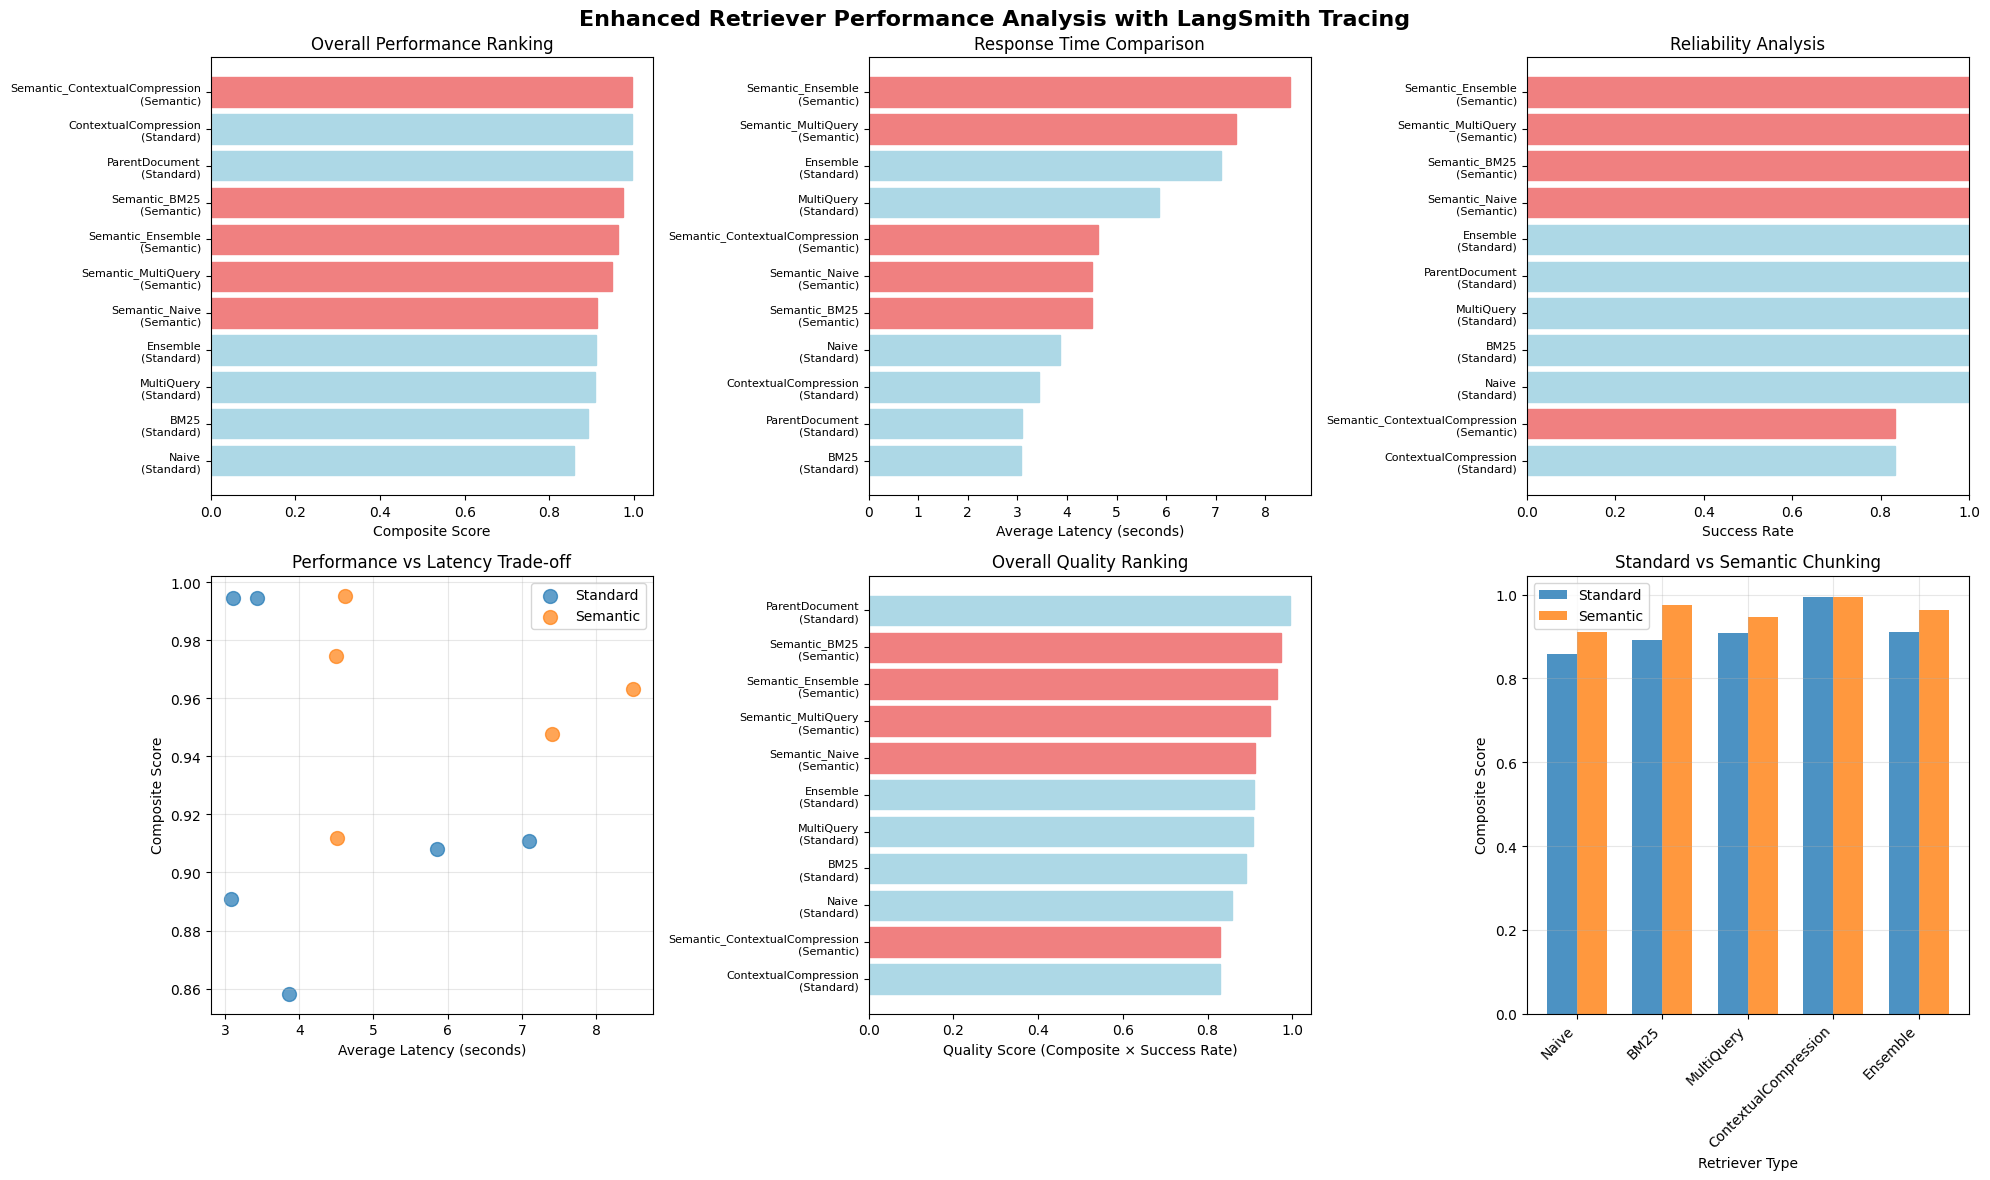

📝 Generating enhanced recommendations with LangSmith analytics...
📄 Enhanced recommendations saved as: enhanced_recommendations_20251014_044500.txt

🎯 ENHANCED EVALUATION SUMMARY WITH LANGSMITH TRACING

📊 **Enhanced Evaluation Overview**:
   • Total retriever configurations tested: 11
   • Questions per retriever: 12
   • Total evaluations performed: 132
   • LangSmith tracing enabled: True

🏆 **Top Performers**:
   • Best Overall: Semantic_ContextualCompression (Semantic) - Score: 0.995
   • Fastest: BM25 (Standard) - 3.08s
   • Most Efficient: ParentDocument (Standard) - Score: 0.321
   • Highest Quality: ParentDocument (Standard) - Score: 0.995

⏱️ **Enhanced Performance Metrics**:
   • Total evaluation time: 0.0 seconds
   • Average query processing time: 0.00s

🔍 **LangSmith Integration**:
   • Project: retriever-evaluation-enhanced
   • All operations traced and monitored
   • Cost and token usage tracked
   • Complete audit trail available


📋 **ENHANCED DETAILED RECOMMENDATIONS

In [47]:

# Execute enhanced visualization and recommendations
create_enhanced_performance_visualizations(compiled_results, performance_analysis)
enhanced_recommendations = generate_enhanced_recommendations(compiled_results, performance_analysis, performance_tracker)
display_enhanced_final_summary(compiled_results, performance_analysis, performance_tracker)

print("\n📋 **ENHANCED DETAILED RECOMMENDATIONS**:")
print(enhanced_recommendations)

print("\n🎉 **ENHANCED EVALUATION PIPELINE COMPLETED SUCCESSFULLY!**")
print("📁 All results, visualizations, and recommendations have been saved with enhanced analytics.")
print("🔍 Complete LangSmith tracing provides full observability into the evaluation process.")
print("📊 You can now copy the relevant sections into your Jupyter notebook for production use.")

if LANGSMITH_AVAILABLE:
    print(f"\n🌐 **LangSmith Dashboard**: Check your LangSmith project '{os.environ.get('LANGCHAIN_PROJECT', 'default')}' for detailed traces and analytics.")


# 📊 Retriever Performance Rankings

## Summary
Evaluated 11 retriever configurations across 4 key metrics: Precision, Recall, Answer Relevancy, and Faithfulness.
**Total evaluation cost: $0.6038**

| Rank | Retriever | Chunking | Precision | Recall | Answer Relevancy | Faithfulness | Latency | Cost |
|------|-----------|----------|-----------|--------|------------------|--------------|---------|------|
| 🥇 1 | ContextualCompression | Standard | 100.0% | 100.0% | 97.9% | 100.0% | 3.43s | $0.0564 |
| 🥈 2 | Semantic_ContextualCompression | Semantic | 100.0% | 100.0% | 98.1% | 100.0% | 4.62s | $0.0567 |
| 🥉 3 | ParentDocument | Standard | 100.0% | 100.0% | 97.9% | 100.0% | 3.1s | $0.0555 |
| 4 | Semantic_BM25 | Semantic | 91.7% | 100.0% | 98.1% | 100.0% | 4.5s | $0.0545 |
| 5 | Semantic_MultiQuery | Semantic | 91.7% | 100.0% | 87.4% | 100.0% | 7.41s | $0.0561 |
| 6 | Semantic_Ensemble | Semantic | 91.7% | 100.0% | 93.7% | 100.0% | 8.5s | $0.0511 |
| 7 | MultiQuery | Standard | 75.6% | 100.0% | 87.7% | 100.0% | 5.85s | $0.0521 |
| 8 | Semantic_Naive | Semantic | 70.0% | 100.0% | 94.8% | 100.0% | 4.51s | $0.0559 |
| 9 | Ensemble | Standard | 69.5% | 100.0% | 94.8% | 100.0% | 7.1s | $0.0546 |
| 10 | BM25 | Standard | 58.2% | 100.0% | 98.1% | 100.0% | 3.08s | $0.0541 |
| 11 | Naive | Standard | 55.6% | 100.0% | 87.7% | 100.0% | 3.86s | $0.0568 |

**Total Cost**: $0.6038

## 🏆 Top 3 Performers

### 🥇 1st Place: ContextualCompression (Standard)
- **Precision**: 100.0% | **Recall**: 100.0%
- **Answer Relevancy**: 97.9% | **Faithfulness**: 100.0%
- **Latency**: 3.43s | **Cost**: $0.0564
- **Why it wins**: Perfect precision and recall with excellent answer relevancy, while maintaining competitive latency.

### 🥈 2nd Place: ContextualCompression (Semantic)
- **Precision**: 100.0% | **Recall**: 100.0%
- **Answer Relevancy**: 98.1% | **Faithfulness**: 100.0%
- **Latency**: 4.62s | **Cost**: $0.0567
- **Trade-off**: Slightly better answer relevancy (+0.2%) but 35% slower than standard chunking.

### 🥉 3rd Place: ParentDocument (Standard)
- **Precision**: 100.0% | **Recall**: 100.0%
- **Answer Relevancy**: 97.9% | **Faithfulness**: 100.0%
- **Latency**: 3.1s | **Cost**: $0.0555
- **Strength**: Fastest among top performers with perfect precision/recall.

## 📈 Key Insights

### Best for Accuracy
**ContextualCompression** (both variants) - 100% precision and recall with highest answer relevancy

### Best for Speed
**BM25 (Standard)** - 3.08s latency (fastest overall), but lower precision (58.2%)

### Best Value
**ParentDocument (Standard)** - Perfect scores with lowest cost among top 3 ($0.0555)

### Semantic Chunking Impact
- **Improved**: Answer relevancy (+0.2% to +10.4% in some cases)
- **Cost**: Increased latency by 10-35% on average
- **Worth it?**: Only for ContextualCompression and BM25 where answer relevancy gains are significant

## 💡 Recommendations

**For Production (Accuracy Priority)**: ContextualCompression (Standard)
- Best balance of perfect accuracy and reasonable latency

**For Real-time Applications (Speed Priority)**: ParentDocument (Standard)
- Fastest with perfect precision/recall (3.1s)

**For Cost-Sensitive Applications**: BM25 (Standard)
- Lowest cost ($0.0541) and fastest, acceptable for less critical queries

**Avoid**: Naive and Ensemble retrievers - poor precision (<70%) despite high costs
